khanesh dadeh va tasvir sazi dadeh

In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('2c13021f-74a9-4289-a1e5-fe0472c89881.csv')

print(data.shape)     # نمایش تعداد سطر و ستون‌های داده
print(data.columns)   # نمایش نام ستون‌های داده


C:\Users\HP\AppData\Local\Temp\ipykernel_4356\931784683.py:4: DtypeWarning: Columns (20,21,74,78,79,80,81,82,83,84,85,184,190) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('2c13021f-74a9-4289-a1e5-fe0472c89881.csv')


(238582, 191)
Index(['_id', 'CRASH_CRN', 'DISTRICT', 'CRASH_COUNTY', 'MUNICIPALITY',
       'POLICE_AGCY', 'CRASH_YEAR', 'CRASH_MONTH', 'DAY_OF_WEEK',
       'TIME_OF_DAY',
       ...
       'LANE_COUNT', 'RDWY_ORIENT', 'ROAD_OWNER', 'ROUTE', 'SPEED_LIMIT',
       'SEGMENT', 'OFFSET', 'STREET_NAME', 'TOT_INJ_COUNT', 'SCHOOL_BUS_UNIT'],
      dtype='object', length=191)


In [2]:
data.describe(include="all")


,_id,CRASH_CRN,DISTRICT,CRASH_COUNTY,MUNICIPALITY,POLICE_AGCY,CRASH_YEAR,CRASH_MONTH,DAY_OF_WEEK,TIME_OF_DAY,...,LANE_COUNT,RDWY_ORIENT,ROAD_OWNER,ROUTE,SPEED_LIMIT,SEGMENT,OFFSET,STREET_NAME,TOT_INJ_COUNT,SCHOOL_BUS_UNIT
count,238582.000000,2.385820e+05,238582.0,238582.0,238582.000000,238447,238582.000000,238582.000000,238582.000000,238431.000000,...,232401.000000,229628,232424.000000,140151.0,225602.000000,138584.000000,148060.000000,226269,80754.000000,24954
unique,NaN,NaN,NaN,NaN,NaN,181,NaN,NaN,NaN,NaN,...,NaN,6,NaN,2100.0,NaN,NaN,NaN,13217,NaN,6
top,NaN,NaN,NaN,NaN,NaN,02301,NaN,NaN,NaN,NaN,...,NaN,N,NaN,0.0,NaN,NaN,NaN,PENN LINCOLN PY,NaN,No
freq,NaN,NaN,NaN,NaN,NaN,71478,NaN,NaN,NaN,NaN,...,NaN,71356,NaN,9582.0,NaN,NaN,NaN,11339,NaN,12388
mean,119291.500000,2.013508e+09,11.0,2.0,2288.426147,NaN,2013.378109,6.581507,4.143502,1445.531265,...,3.512218,NaN,2.852911,NaN,34.440940,221.613419,1001.996008,NaN,0.532197,NaN
std,68872.835299,5.642491e+06,0.0,0.0,120.440481,NaN,5.705368,3.561530,1.968479,1241.318352,...,11.244462,NaN,1.169457,NaN,11.401586,241.600522,990.631832,NaN,0.810571,NaN
min,1.000000,2.004000e+09,11.0,2.0,2101.000000,NaN,2004.000000,1.000000,1.000000,0.000000,...,0.000000,NaN,1.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN
25%,59646.250000,2.008138e+09,11.0,2.0,2207.000000,NaN,2008.000000,3.000000,2.000000,851.000000,...,2.000000,NaN,2.000000,NaN,25.000000,30.000000,0.000000,NaN,0.000000,NaN
50%,119291.500000,2.013130e+09,11.0,2.0,2301.000000,NaN,2013.000000,7.000000,4.000000,1422.000000,...,2.000000,NaN,2.000000,NaN,35.000000,113.000000,762.000000,NaN,0.000000,NaN
75%,178936.750000,2.018099e+09,11.0,2.0,2407.000000,NaN,2018.000000,10.000000,6.000000,1759.000000,...,2.000000,NaN,4.000000,NaN,40.000000,340.000000,1684.000000,NaN,1.000000,NaN


In [4]:
import pandas as pd

# بررسی وجود داده‌های تکراری
duplicates = data.duplicated()

# نمایش تعداد کل داده‌های تکراری
print(f"تعداد داده‌های تکراری: {duplicates.sum()}")

# نمایش سطرهای تکراری (در صورت وجود)
if duplicates.sum() > 0:
    print("ردیف‌های تکراری:")
    print(data[duplicates])

# حذف داده‌های تکراری (در صورت نیاز)
data_no_duplicates = data.drop_duplicates()

# نمایش تعداد داده‌های پس از حذف تکراری‌ها
print(f"تعداد داده‌ها پس از حذف تکراری‌ها: {data_no_duplicates.shape[0]}")


تعداد داده‌های تکراری: 0
تعداد داده‌ها پس از حذف تکراری‌ها: 238582


In [4]:
import pandas as pd

# بارگذاری داده‌ها از فایل CSV
df = pd.read_csv('2c13021f-74a9-4289-a1e5-fe0472c89881.csv')

# تغییر نام ستون‌ها
df = df.rename(columns={
    'CRASH_YEAR': 'Year',
    'CRASH_MONTH': 'Month',
    'DAY_OF_WEEK': 'Day_of_Week',
    'HOUR_OF_DAY': 'Hour'
})

# جابجایی ستون‌های مربوط به زمان به ابتدای جدول
time_columns = ['Year', 'Month', 'Day_of_Week', 'Hour']
df = df[time_columns + [col for col in df.columns if col not in time_columns]]

# نمایش ۵ سطر اول برای بررسی
print(df.head())

# مسیر خروجی فایل جدید
output_path = "accident_data_with_time_features.csv"

# ذخیره داده‌های پردازش‌شده
df.to_csv(output_path, index=False)

print(f"✅ داده‌های پردازش‌شده در فایل ذخیره شد: {output_path}")


C:\Users\HP\AppData\Local\Temp\ipykernel_4992\2661681635.py:4: DtypeWarning: Columns (20,21,74,78,79,80,81,82,83,84,85,184,190) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('2c13021f-74a9-4289-a1e5-fe0472c89881.csv')


   Year  Month  Day_of_Week  Hour  _id   CRASH_CRN  DISTRICT  CRASH_COUNTY  \
0  2004      1            5   2.0    1  2004000001        11             2   
1  2004      1            5  10.0    2  2004000010        11             2   
2  2004      1            5  18.0    3  2004000016        11             2   
3  2004      1            6   9.0    4  2004000022        11             2   
4  2004      1            5  22.0    5  2004000030        11             2   

   MUNICIPALITY POLICE_AGCY  ...  LANE_COUNT  RDWY_ORIENT  ROAD_OWNER  ROUTE  \
0          2454       02454  ...         2.0            E         2.0   2032   
1          2440       02440  ...         2.0            W         3.0    NaN   
2          2203       02203  ...         2.0            W         2.0   3082   
3          2404       02404  ...         2.0            N         4.0    NaN   
4          2419       02419  ...         2.0            S         4.0    NaN   

   SPEED_LIMIT  SEGMENT  OFFSET           STREET_N

In [5]:
# سال‌های مورد نظر برای جدا کردن
years_to_filter = [2023]

# فیلتر کردن داده‌ها برای سال‌های مشخص شده
df_filtered = df[df['Year'].isin(years_to_filter)]

# نمایش ۵ سطر اول برای بررسی
print(df_filtered.head())

# اگر بخواهید داده‌ها را در فایل جدید ذخیره کنید
output_path = "accident_data_filtered.csv"
df_filtered.to_csv(output_path, index=False)

print(f"✅ داده‌های فیلتر شده در فایل ذخیره شد: {output_path}")


        Year  Month  Day_of_Week  Hour     _id   CRASH_CRN  DISTRICT  \
219161  2023      3            7  23.0  219162  2022028692        11   
228213  2023      1            1   1.0  228214  2023000015        11   
228214  2023      1            1   1.0  228215  2023000073        11   
228215  2023      1            1   6.0  228216  2023000089        11   
228216  2023      1            1  12.0  228217  2023000155        11   

        CRASH_COUNTY  MUNICIPALITY POLICE_AGCY  ...  LANE_COUNT  RDWY_ORIENT  \
219161             2          2438       02438  ...         2.0            E   
228213             2          2466       02466  ...         2.0            N   
228214             2          2301       02301  ...         3.0            E   
228215             2          2301       02301  ...         2.0            E   
228216             2          2404       02404  ...         1.0            N   

        ROAD_OWNER  ROUTE  SPEED_LIMIT  SEGMENT  OFFSET   STREET_NAME  \
219161       

In [6]:
import pandas as pd
import numpy as np

# بارگذاری داده‌ها از فایل CSV (اطمینان از اینکه داده‌ها در این متغیر قرار دارد)
data = pd.read_csv('accident_data_filtered.csv')

# ایجاد یک ستون جدید SEVERITY با استفاده از شروط برداری
conditions = [
    (data['FATAL'] > 0),
    (data['FATAL_OR_MAJ_INJ'] > 0),
    (data['INJURY'] > 0),
    (data['PROPERTY_DAMAGE_ONLY'] > 0)
]

# مقادیر متناظر با هر شرط
choices = ['Fatal', 'Serious', 'Minor', 'Property Damage']

# ایجاد ستون SEVERITY
data['SEVERITY'] = np.select(conditions, choices, default='No Injury')

data = data[data['Hour'] < 24]  # حذف ساعت‌های اشتباه

# ذخیره داده‌ها در یک فایل اکسل
output_path = 'accident_data_with_severity2.csv'
data.to_csv(output_path, index=False, encoding='utf-8')


print(f'✅ فایل ذخیره شد: {output_path}')


✅ فایل ذخیره شد: accident_data_with_severity2.csv


In [7]:
import pandas as pd

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)


In [8]:
data.describe(include="all")


,Year,Month,Day_of_Week,Hour,_id,CRASH_CRN,DISTRICT,CRASH_COUNTY,MUNICIPALITY,POLICE_AGCY,TIME_OF_DAY,ILLUMINATION,WEATHER,ROAD_CONDITION,COLLISION_TYPE,RELATION_TO_ROAD,INTERSECT_TYPE,TCD_TYPE,URBAN_RURAL,LOCATION_TYPE,SCH_BUS_IND,SCH_ZONE_IND,TOTAL_UNITS,PERSON_COUNT,VEHICLE_COUNT,AUTOMOBILE_COUNT,MOTORCYCLE_COUNT,BUS_COUNT,SMALL_TRUCK_COUNT,HEAVY_TRUCK_COUNT,SUV_COUNT,VAN_COUNT,BICYCLE_COUNT,FATAL_COUNT,INJURY_COUNT,MAJ_INJ_COUNT,MOD_INJ_COUNT,MIN_INJ_COUNT,UNK_INJ_DEG_COUNT,UNK_INJ_PER_COUNT,UNBELTED_OCC_COUNT,UNB_DEATH_COUNT,UNB_MAJ_INJ_COUNT,BELTED_DEATH_COUNT,BELTED_MAJ_INJ_COUNT,MCYCLE_DEATH_COUNT,MCYCLE_MAJ_INJ_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_MAJ_INJ_COUNT,PED_COUNT,PED_DEATH_COUNT,PED_MAJ_INJ_COUNT,COMM_VEH_COUNT,MAX_SEVERITY_LEVEL,DRIVER_COUNT_16YR,DRIVER_COUNT_17YR,DRIVER_COUNT_18YR,DRIVER_COUNT_19YR,DRIVER_COUNT_20YR,DRIVER_COUNT_50_64YR,DRIVER_COUNT_65_74YR,DRIVER_COUNT_75PLUS,LATITUDE,LONGITUDE,DEC_LAT,DEC_LONG,EST_HRS_CLOSED,LANE_CLOSED,LN_CLOSE_DIR,NTFY_HIWY_MAINT,RDWY_SURF_TYPE_CD,SPEC_JURIS_CD,TCD_FUNC_CD,TFC_DETOUR_IND,WORK_ZONE_IND,WORK_ZONE_TYPE,WORK_ZONE_LOC,CONS_ZONE_SPD_LIM,WORKERS_PRES,WZ_CLOSE_DETOUR,WZ_FLAGGER,WZ_LAW_OFFCR_IND,WZ_LN_CLOSURE,WZ_MOVING,WZ_OTHER,WZ_SHLDER_MDN,FLAG_CRN,INTERSTATE,STATE_ROAD,LOCAL_ROAD,LOCAL_ROAD_ONLY,TURNPIKE,WET_ROAD,SNOW_SLUSH_ROAD,ICY_ROAD,SUDDEN_DEER,SHLDR_RELATED,REAR_END,HO_OPPDIR_SDSWP,HIT_FIXED_OBJECT,SV_RUN_OFF_RD,WORK_ZONE,PROPERTY_DAMAGE_ONLY,FATAL_OR_MAJ_INJ,INJURY,FATAL,NON_INTERSECTION,INTERSECTION,SIGNALIZED_INT,STOP_CONTROLLED_INT,UNSIGNALIZED_INT,SCHOOL_BUS,SCHOOL_ZONE,HIT_DEER,HIT_TREE_SHRUB,HIT_EMBANKMENT,HIT_POLE,HIT_GDRAIL,HIT_GDRAIL_END,HIT_BARRIER,HIT_BRIDGE,OVERTURNED,MOTORCYCLE,BICYCLE,HVY_TRUCK_RELATED,VEHICLE_FAILURE,TRAIN_TROLLEY,PHANTOM_VEHICLE,ALCOHOL_RELATED,DRINKING_DRIVER,UNDERAGE_DRNK_DRV,UNLICENSED,CELL_PHONE,NO_CLEARANCE,RUNNING_RED_LT,TAILGATING,CROSS_MEDIAN,CURVE_DVR_ERROR,LIMIT_65MPH,SPEEDING,SPEEDING_RELATED,AGGRESSIVE_DRIVING,FATIGUE_ASLEEP,DRIVER_16YR,DRIVER_17YR,DRIVER_65_74YR,DRIVER_75PLUS,UNBELTED,PEDESTRIAN,DISTRACTED,CURVED_ROAD,DRIVER_18YR,DRIVER_19YR,DRIVER_20YR,DRIVER_50_64YR,VEHICLE_TOWED,FIRE_IN_VEHICLE,HIT_PARKED_VEHICLE,MC_DRINKING_DRIVER,DRUGGED_DRIVER,INJURY_OR_FATAL,COMM_VEHICLE,IMPAIRED_DRIVER,DEER_RELATED,DRUG_RELATED,HAZARDOUS_TRUCK,ILLEGAL_DRUG_RELATED,ILLUMINATION_DARK,MINOR_INJURY,MODERATE_INJURY,MAJOR_INJURY,NHTSA_AGG_DRIVING,PSP_REPORTED,RUNNING_STOP_SIGN,TRAIN,TROLLEY,ROADWAY_CRN,RDWY_SEQ_NUM,ADJ_RDWY_SEQ,ACCESS_CTRL,ROADWAY_COUNTY,LANE_COUNT,RDWY_ORIENT,ROAD_OWNER,ROUTE,SPEED_LIMIT,SEGMENT,OFFSET,STREET_NAME,TOT_INJ_COUNT,SCHOOL_BUS_UNIT,SEVERITY
count,10301.0,10301.000000,10301.000000,10301.000000,10301.000000,1.030100e+04,10301.0,10301.0,10301.000000,10301,10301.000000,10301.000000,10286.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10172.000000,10158.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,0.0,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10297,10297,10293.000000,10294.000000,0.0,10301.000000,5243.000000,10301,74.000000,74.000000,10301.000000,5593,10301.000000,156.000000,156.000000,156.000000,156,46.000000,58.000000,156,105.000000,67.000000,57.000000,77.00000,1.030100e+04,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000

In [9]:
print(data['Hour'].value_counts())


Hour
16.0    758
15.0    749
17.0    742
18.0    619
14.0    590
13.0    525
12.0    504
7.0     501
19.0    469
8.0     448
11.0    416
9.0     394
21.0    388
20.0    385
10.0    377
6.0     349
23.0    348
22.0    331
0.0     329
2.0     311
1.0     271
3.0     186
5.0     174
4.0     137
Name: count, dtype: int64


In [10]:
import pandas as pd

# نمایش کامل نام ستون‌ها بدون محدودیت
pd.set_option('display.max_columns', None)

# نمایش نام تمام ستون‌ها
print(list(data.columns))


['Year', 'Month', 'Day_of_Week', 'Hour', '_id', 'CRASH_CRN', 'DISTRICT', 'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY', 'TIME_OF_DAY', 'ILLUMINATION', 'WEATHER', 'ROAD_CONDITION', 'COLLISION_TYPE', 'RELATION_TO_ROAD', 'INTERSECT_TYPE', 'TCD_TYPE', 'URBAN_RURAL', 'LOCATION_TYPE', 'SCH_BUS_IND', 'SCH_ZONE_IND', 'TOTAL_UNITS', 'PERSON_COUNT', 'VEHICLE_COUNT', 'AUTOMOBILE_COUNT', 'MOTORCYCLE_COUNT', 'BUS_COUNT', 'SMALL_TRUCK_COUNT', 'HEAVY_TRUCK_COUNT', 'SUV_COUNT', 'VAN_COUNT', 'BICYCLE_COUNT', 'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT', 'UNK_INJ_DEG_COUNT', 'UNK_INJ_PER_COUNT', 'UNBELTED_OCC_COUNT', 'UNB_DEATH_COUNT', 'UNB_MAJ_INJ_COUNT', 'BELTED_DEATH_COUNT', 'BELTED_MAJ_INJ_COUNT', 'MCYCLE_DEATH_COUNT', 'MCYCLE_MAJ_INJ_COUNT', 'BICYCLE_DEATH_COUNT', 'BICYCLE_MAJ_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT', 'PED_MAJ_INJ_COUNT', 'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL', 'DRIVER_COUNT_16YR', 'DRIVER_COUNT_17YR', 'DRIVER_COUNT_18YR', 'DRIVER_COUNT_19YR', 

In [11]:
import pandas as pd

# محاسبه تعداد تصادفات در بازه‌های زمانی مختلف
daily_stats = data.groupby(['Year', 'Month', 'Day_of_Week'])['_id'].count().describe()
monthly_stats = data.groupby(['Year', 'Month'])['_id'].count().describe()
yearly_stats = data.groupby(['Year'])['_id'].count().describe()

print("آمار روزانه:\n", daily_stats)
print("\nآمار ماهانه:\n", monthly_stats)
print("\nآمار سالانه:\n", yearly_stats)


آمار روزانه:
 count     84.000000
mean     122.630952
std       21.162469
min       84.000000
25%      105.000000
50%      120.500000
75%      137.000000
max      170.000000
Name: _id, dtype: float64

آمار ماهانه:
 count     12.000000
mean     858.416667
std       74.472031
min      687.000000
25%      844.750000
50%      882.000000
75%      899.250000
max      966.000000
Name: _id, dtype: float64

آمار سالانه:
 count        1.0
mean     10301.0
std          NaN
min      10301.0
25%      10301.0
50%      10301.0
75%      10301.0
max      10301.0
Name: _id, dtype: float64


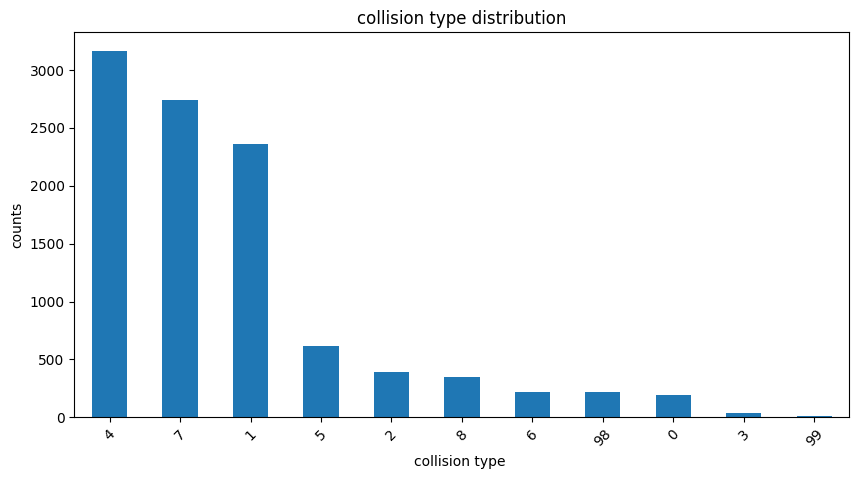

In [12]:
import matplotlib.pyplot as plt

# توزیع نوع تصادف
collision_distribution = data['COLLISION_TYPE'].value_counts()

# رسم نمودار
plt.figure(figsize=(10, 5))
collision_distribution.plot(kind='bar')
plt.xlabel('collision type ')
plt.ylabel('counts')
plt.title('collision type distribution')
plt.xticks(rotation=45)
plt.show()


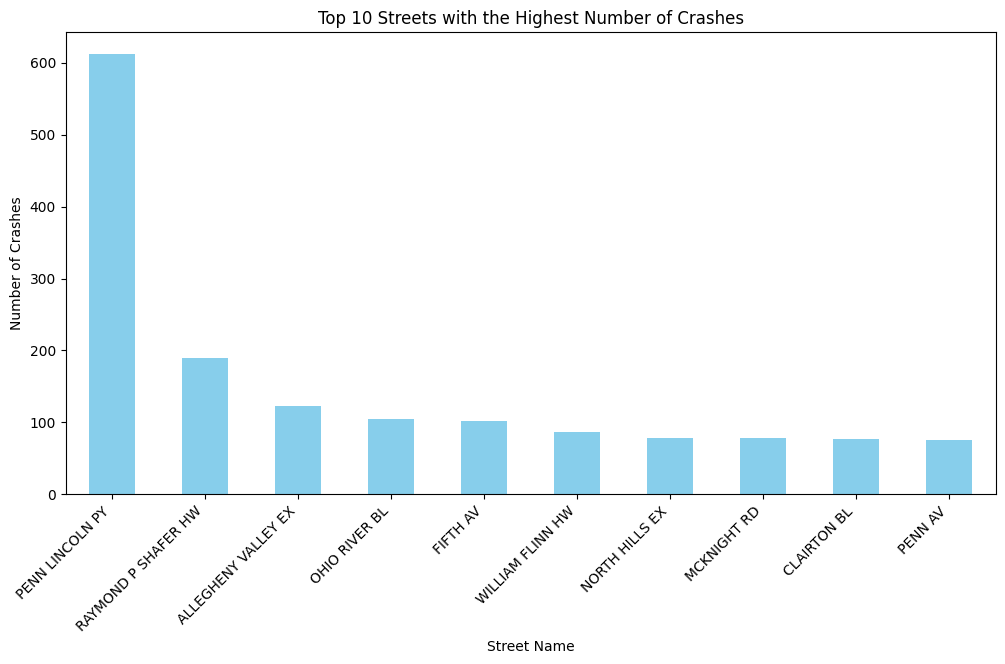

In [13]:
import matplotlib.pyplot as plt

# توزیع تصادفات بر اساس خیابان
street_accidents = data['STREET_NAME'].value_counts()

# نمایش ۱۰ خیابان با بیشترین تصادف
top_10_streets = street_accidents.head(10)

# رسم نمودار
plt.figure(figsize=(12, 6))
top_10_streets.plot(kind='bar', color='skyblue')

# تنظیم عناوین و برچسب‌ها به انگلیسی
plt.xlabel('Street Name')
plt.ylabel('Number of Crashes')
plt.title('Top 10 Streets with the Highest Number of Crashes')

# چرخاندن برچسب‌های محور X برای خوانایی بهتر
plt.xticks(rotation=45, ha='right')

# نمایش نمودار
plt.show()



Crash distribution by weather condition:
 WEATHER
3.0     7963
7.0     1303
4.0      655
10.0     173
2.0       53
99.0      43
98.0      42
6.0       27
5.0       18
9.0        4
1.0        3
8.0        2
Name: count, dtype: int64

Crash distribution by illumination condition:
 ILLUMINATION
1    6327
3    2901
2     627
4     191
5     185
6      58
8      12
Name: count, dtype: int64


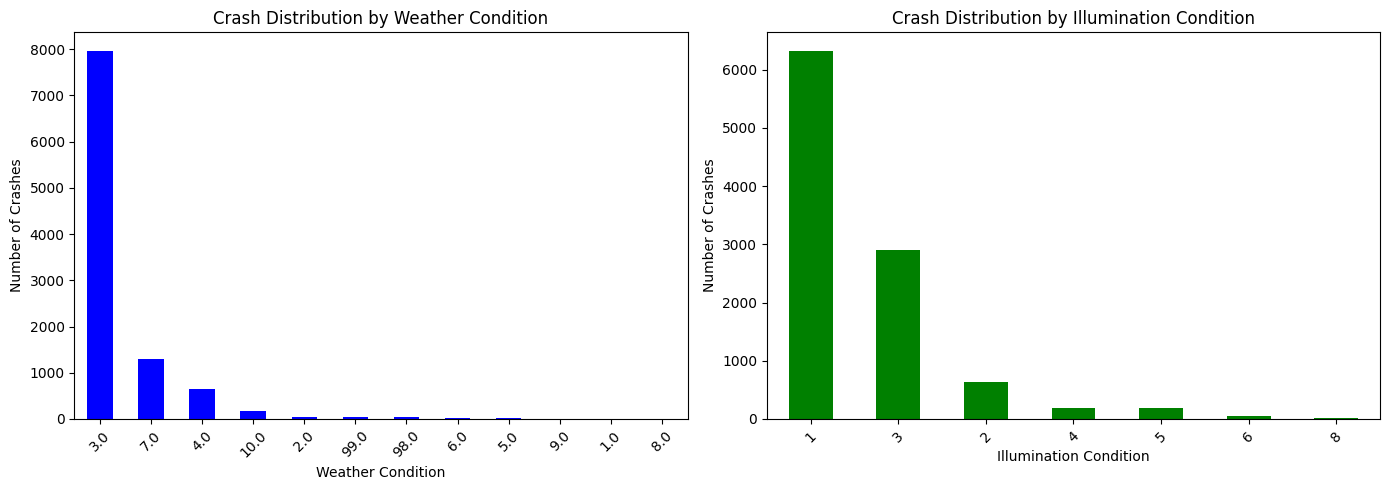

In [14]:
import matplotlib.pyplot as plt

# بررسی تعداد تصادفات در شرایط جوی مختلف
weather_accidents = data['WEATHER'].value_counts()

# بررسی تعداد تصادفات در شرایط روشنایی مختلف
illumination_accidents = data['ILLUMINATION'].value_counts()

# نمایش آمار
print("Crash distribution by weather condition:\n", weather_accidents)
print("\nCrash distribution by illumination condition:\n", illumination_accidents)

# رسم نمودار
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_accidents.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Crash Distribution by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Number of Crashes')

illumination_accidents.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Crash Distribution by Illumination Condition')
axes[1].set_xlabel('Illumination Condition')
axes[1].set_ylabel('Number of Crashes')

# چرخاندن برچسب‌های محور X برای خوانایی بهتر
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


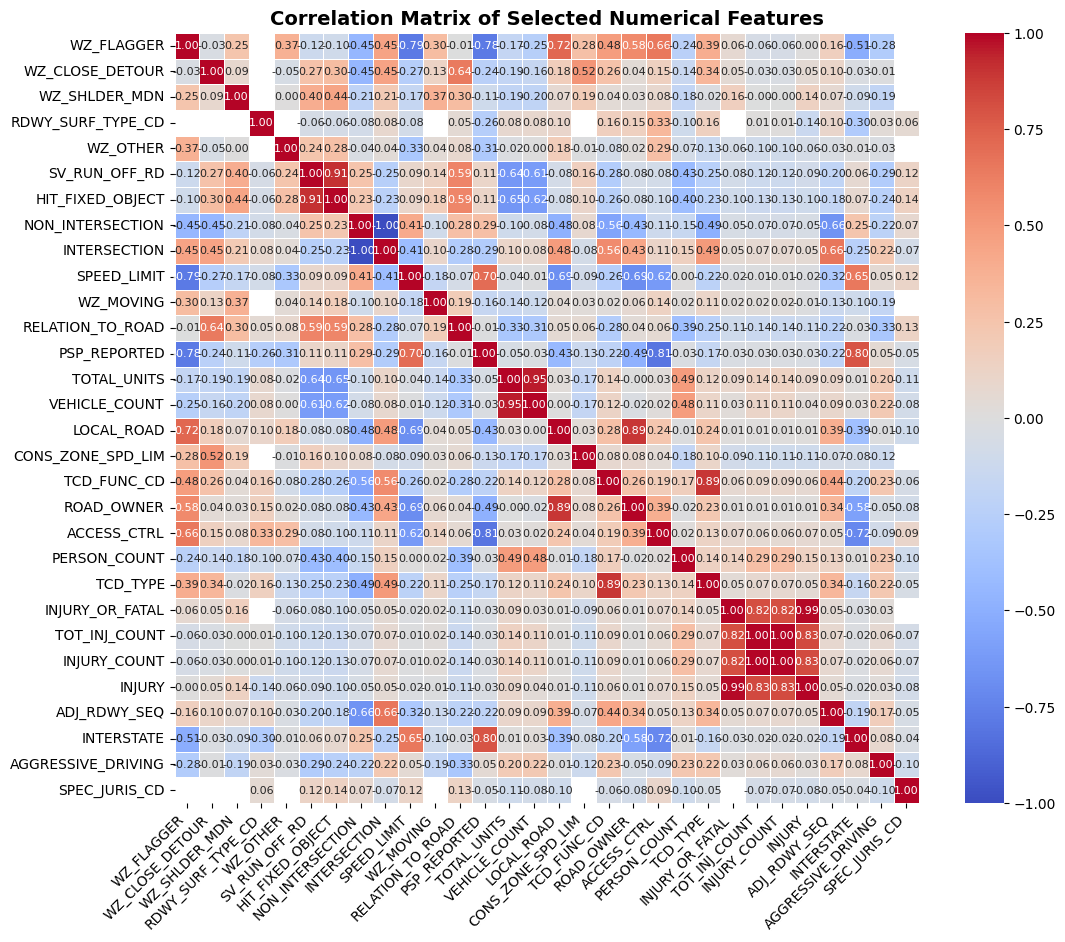

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# حذف ستون‌های غیرعددی
df_numeric = data.select_dtypes(include=['number'])

# محاسبه ماتریس همبستگی
corr_matrix = df_numeric.corr()

# انتخاب مهم‌ترین ویژگی‌ها (مثلاً متغیرهایی که بیشترین همبستگی را دارند)
important_features = corr_matrix.abs().mean().sort_values(ascending=False).head(30).index
corr_matrix_filtered = corr_matrix.loc[important_features, important_features]

# تنظیم ابعاد و رسم Heatmap با بهینه‌سازی خوانایی
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_filtered, 
            annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, 
            annot_kws={"size": 8}, 
            vmax=1, vmin=-1, center=0)

# تنظیم فونت و چرخش عناوین
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# اضافه کردن عنوان
plt.title("Correlation Matrix of Selected Numerical Features", fontsize=14, fontweight="bold")

# نمایش نمودار
plt.show()


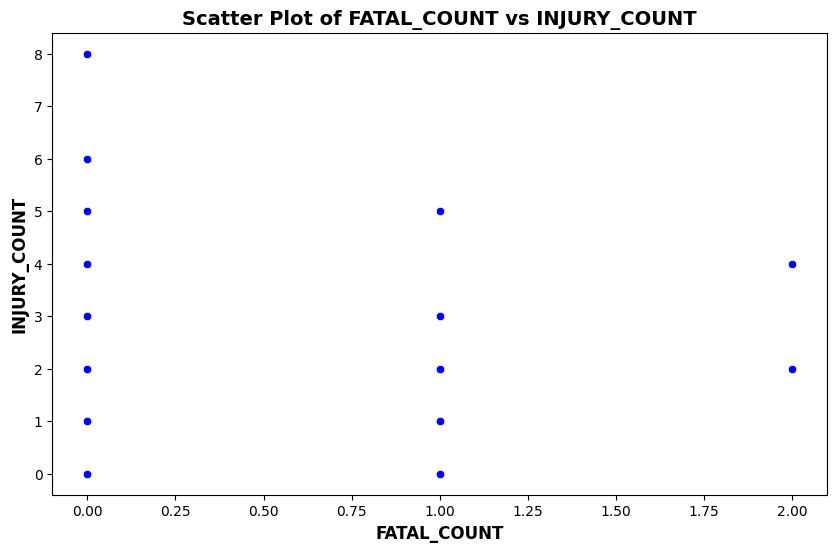

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# انتخاب دو متغیر عددی برای رسم نمودار پراکندگی
numerical_var1 = 'FATAL_COUNT'  # متغیر عددی 1
numerical_var2 = 'INJURY_COUNT'  # متغیر عددی 2

# بررسی اینکه متغیرهای انتخابی در داده وجود دارند
if numerical_var1 in data.columns and numerical_var2 in data.columns:
    plt.figure(figsize=(10, 6))
    
    # رسم نمودار پراکندگی
    sns.scatterplot(x=data[numerical_var1], y=data[numerical_var2], marker='o', color='b')
    
    # تنظیمات بصری
    plt.xlabel(numerical_var1, fontsize=12, fontweight="bold")
    plt.ylabel(numerical_var2, fontsize=12, fontweight="bold")
    plt.title(f"Scatter Plot of {numerical_var1} vs {numerical_var2}", fontsize=14, fontweight="bold")
    
    # نمایش نمودار
    plt.show()
else:
    print(f"یکی از متغیرهای انتخابی ({numerical_var1} یا {numerical_var2}) در داده‌ها وجود ندارد.")


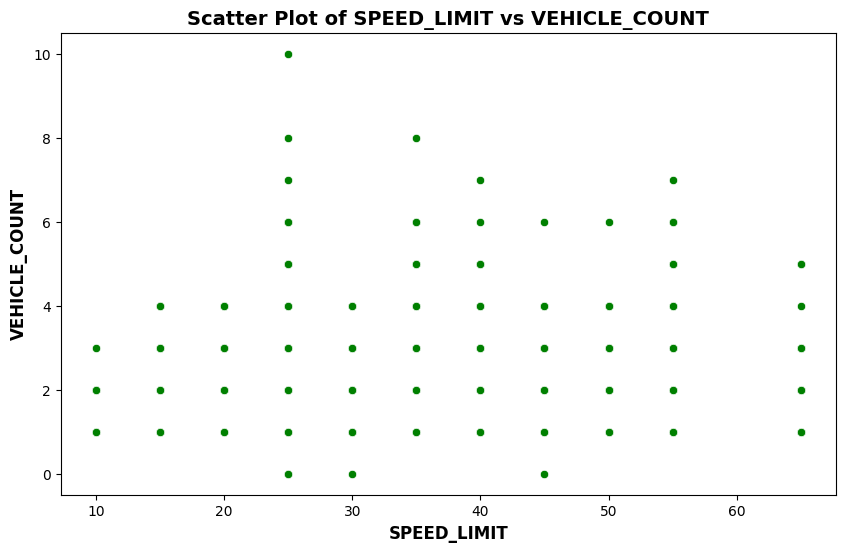

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# انتخاب دو متغیر عددی برای رسم نمودار پراکندگی
numerical_var1 = 'SPEED_LIMIT'  # متغیر عددی 1
numerical_var2 = 'VEHICLE_COUNT'  # متغیر عددی 2

# بررسی اینکه متغیرهای انتخابی در داده وجود دارند
if numerical_var1 in data.columns and numerical_var2 in data.columns:
    plt.figure(figsize=(10, 6))
    
    # رسم نمودار پراکندگی
    sns.scatterplot(x=data[numerical_var1], y=data[numerical_var2], marker='o', color='g')
    
    # تنظیمات بصری
    plt.xlabel(numerical_var1, fontsize=12, fontweight="bold")
    plt.ylabel(numerical_var2, fontsize=12, fontweight="bold")
    plt.title(f"Scatter Plot of {numerical_var1} vs {numerical_var2}", fontsize=14, fontweight="bold")
    
    # نمایش نمودار
    plt.show()
else:
    print(f"یکی از متغیرهای انتخابی ({numerical_var1} یا {numerical_var2}) در داده‌ها وجود ندارد.")


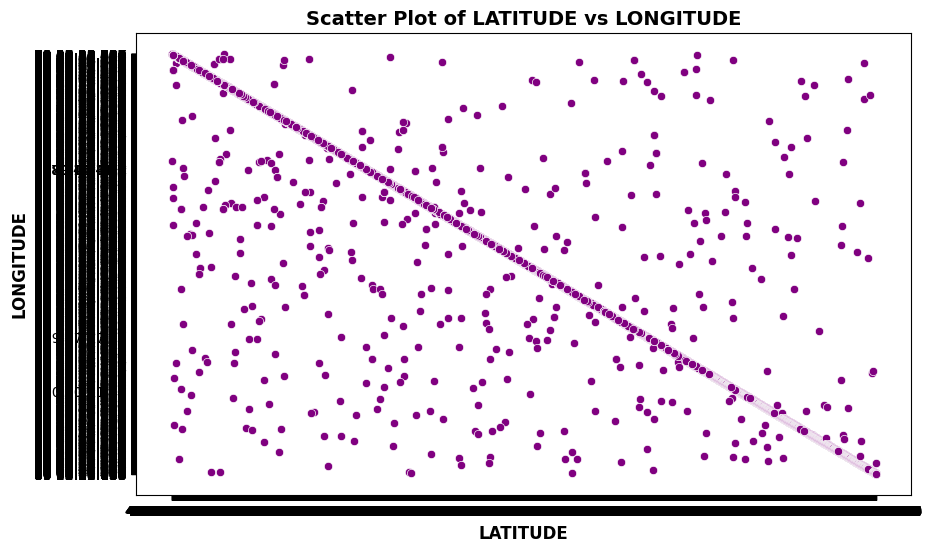

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# انتخاب دو متغیر عددی برای رسم نمودار پراکندگی
numerical_var1 = 'LATITUDE'  # متغیر عددی 1
numerical_var2 = 'LONGITUDE'  # متغیر عددی 2

# بررسی اینکه متغیرهای انتخابی در داده وجود دارند
if numerical_var1 in data.columns and numerical_var2 in data.columns:
    plt.figure(figsize=(10, 6))
    
    # رسم نمودار پراکندگی
    sns.scatterplot(x=data[numerical_var1], y=data[numerical_var2], marker='o', color='purple')
    
    # تنظیمات بصری
    plt.xlabel(numerical_var1, fontsize=12, fontweight="bold")
    plt.ylabel(numerical_var2, fontsize=12, fontweight="bold")
    plt.title(f"Scatter Plot of {numerical_var1} vs {numerical_var2}", fontsize=14, fontweight="bold")
    
    # نمایش نمودار
    plt.show()
else:
    print(f"یکی از متغیرهای انتخابی ({numerical_var1} یا {numerical_var2}) در داده‌ها وجود ندارد.")


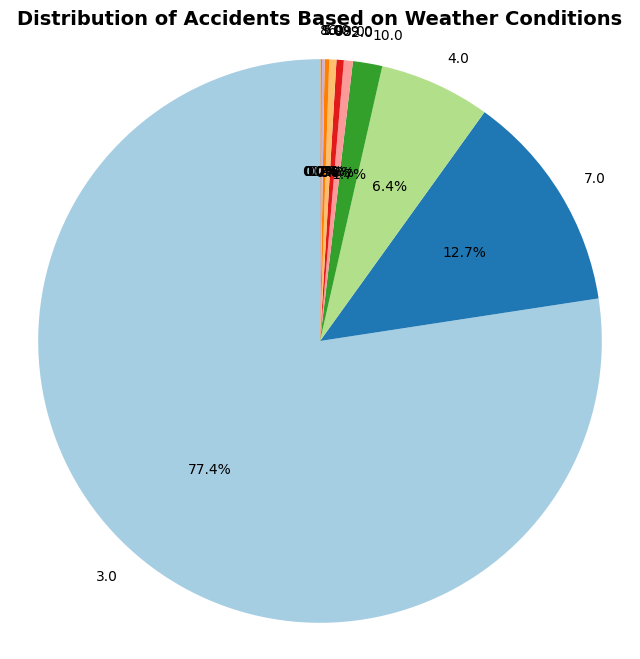

In [19]:
import matplotlib.pyplot as plt

# محاسبه توزیع شرایط جوی
weather_counts = data['WEATHER'].value_counts()

# رسم نمودار دایره‌ای
plt.figure(figsize=(8, 8))
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Distribution of Accidents Based on Weather Conditions", fontsize=14, fontweight="bold")
plt.axis('equal')  # دایره‌ای بودن نمودار
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_4992\310553279.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='ROAD_CONDITION', palette='coolwarm')


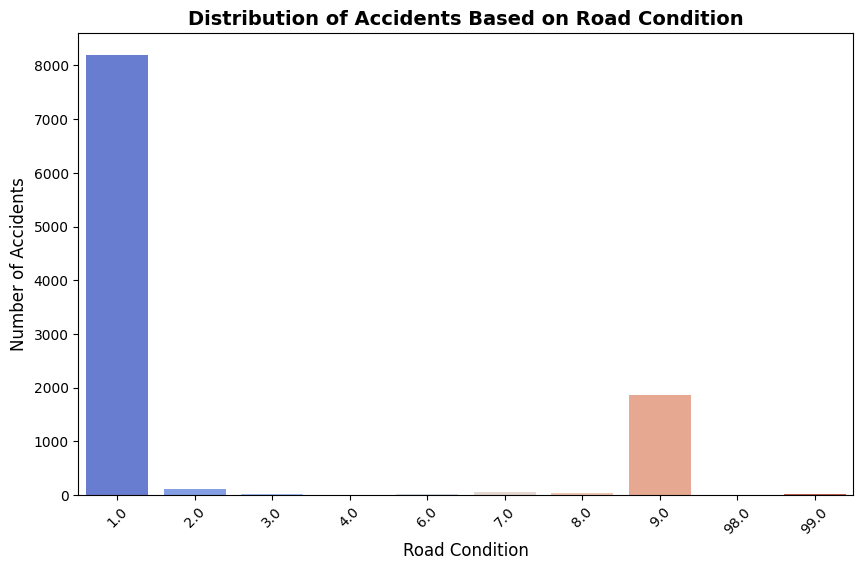

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار میلهای برای وضعیت جاده
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='ROAD_CONDITION', palette='coolwarm')
plt.title("Distribution of Accidents Based on Road Condition", fontsize=14, fontweight="bold")
plt.xlabel('Road Condition', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.show()


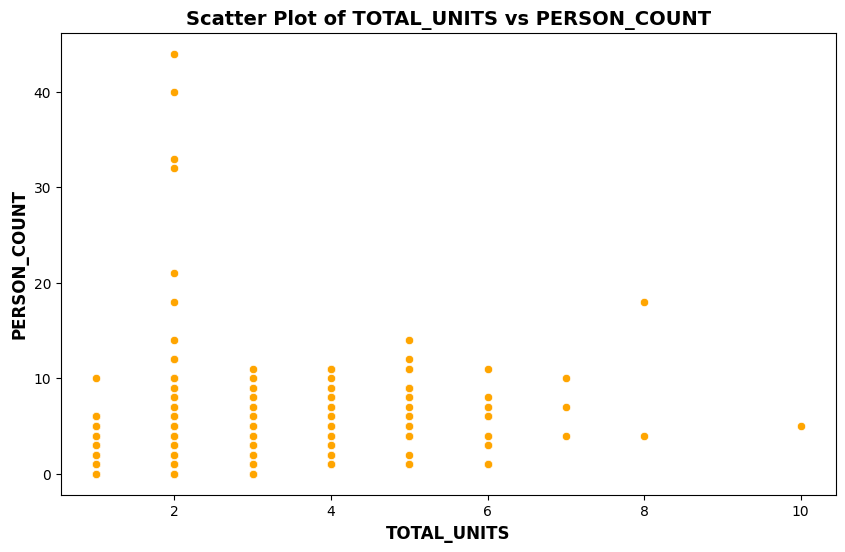

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# انتخاب دو متغیر عددی برای رسم نمودار پراکندگی
numerical_var1 = 'TOTAL_UNITS'  # متغیر عددی 1
numerical_var2 = 'PERSON_COUNT'  # متغیر عددی 2

# بررسی اینکه متغیرهای انتخابی در داده وجود دارند
if numerical_var1 in data.columns and numerical_var2 in data.columns:
    plt.figure(figsize=(10, 6))
    
    # رسم نمودار پراکندگی
    sns.scatterplot(x=data[numerical_var1], y=data[numerical_var2], marker='o', color='orange')
    
    # تنظیمات بصری
    plt.xlabel(numerical_var1, fontsize=12, fontweight="bold")
    plt.ylabel(numerical_var2, fontsize=12, fontweight="bold")
    plt.title(f"Scatter Plot of {numerical_var1} vs {numerical_var2}", fontsize=14, fontweight="bold")
    
    # نمایش نمودار
    plt.show()
else:
    print(f"یکی از متغیرهای انتخابی ({numerical_var1} یا {numerical_var2}) در داده‌ها وجود ندارد.")


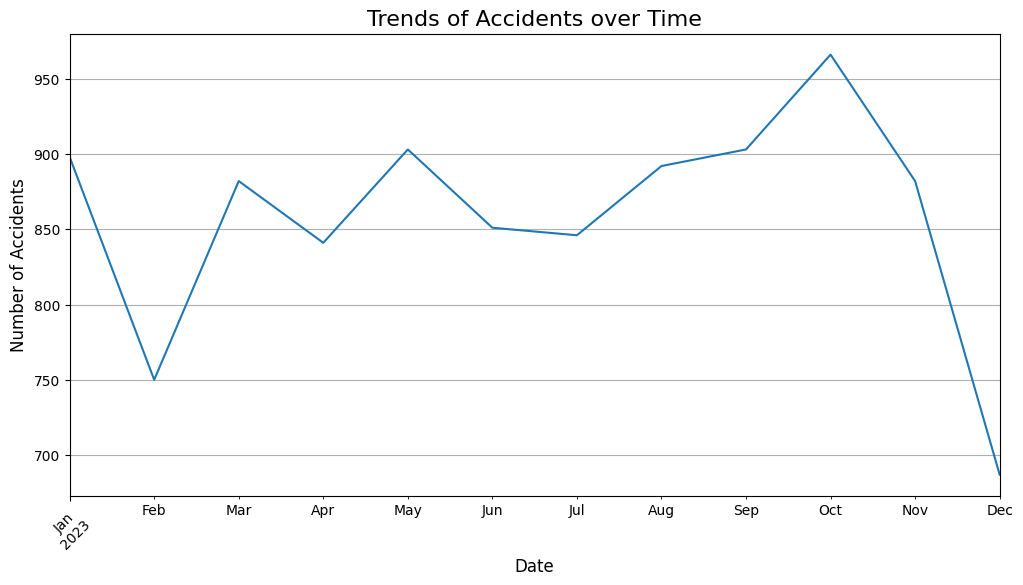

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# فرض بر این است که داده‌ها در DataFrame به نام data قرار دارند
# ایجاد یک تاریخ ترکیبی از سال و ماه برای تجزیه و تحلیل
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))

# گروه‌بندی داده‌ها بر اساس ماه و سال
monthly_accidents = data.groupby('Date').size()

# رسم نمودار سری زمانی
plt.figure(figsize=(12, 6))
monthly_accidents.plot()
plt.title('Trends of Accidents over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_4992\4039592012.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ROAD_CONDITION', y='SEVERITY', data=data, palette='coolwarm')


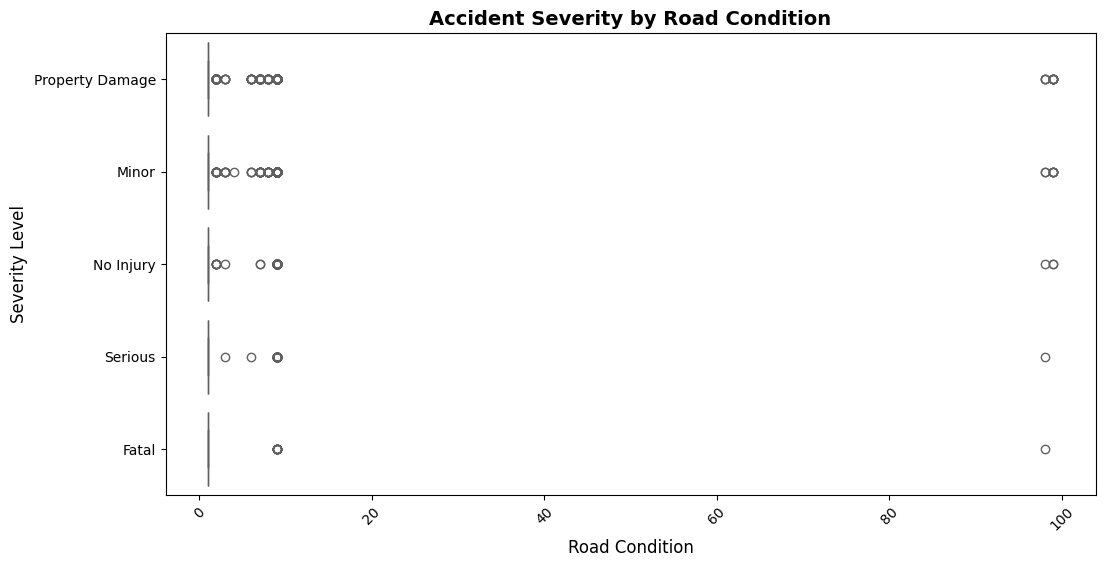

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار جعبه‌ای برای شدت تصادفات
plt.figure(figsize=(12, 6))
sns.boxplot(x='ROAD_CONDITION', y='SEVERITY', data=data, palette='coolwarm')
plt.title("Accident Severity by Road Condition", fontsize=14, fontweight="bold")
plt.xlabel('Road Condition', fontsize=12)
plt.ylabel('Severity Level', fontsize=12)
plt.xticks(rotation=45)
plt.show()


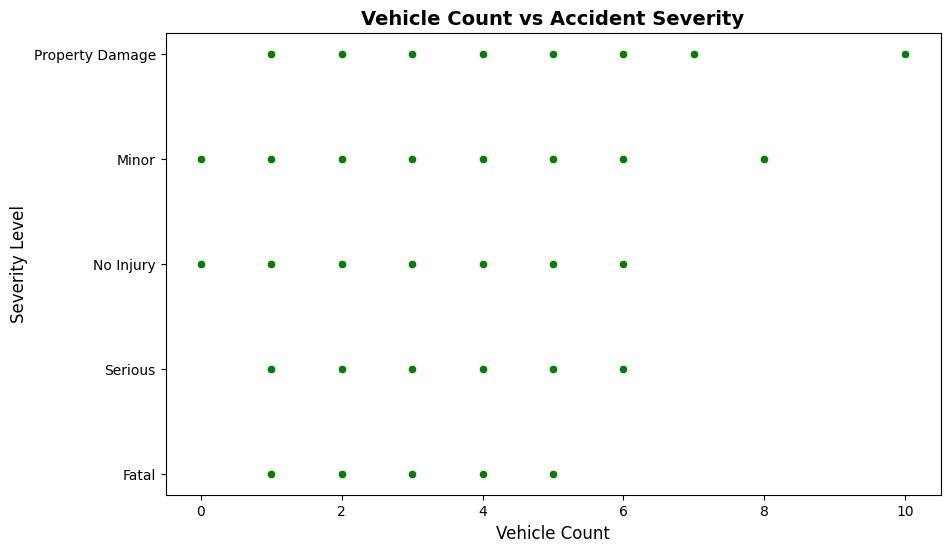

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم نمودار پراکندگی
plt.figure(figsize=(10, 6))
sns.scatterplot(x='VEHICLE_COUNT', y='SEVERITY', data=data, color='g', marker='o')
plt.title("Vehicle Count vs Accident Severity", fontsize=14, fontweight="bold")
plt.xlabel('Vehicle Count', fontsize=12)
plt.ylabel('Severity Level', fontsize=12)
plt.show()


gereftan shabakeh rahha az osm 

In [25]:
import osmnx as ox
import geopandas as gpd

# تنظیمات OSMnx برای ذخیره کش (کاهش زمان درخواست‌های بعدی)
ox.settings.use_cache = True  

# بارگیری شبکه جاده‌ای برای شهرستان Allegheny
G = ox.graph_from_place("Allegheny County, Pennsylvania, USA", network_type="drive")

# نمایش اطلاعات کلی گراف
print(f"گراف دارای {len(G.nodes)} گره و {len(G.edges)} یال است.")


گراف دارای 48398 گره و 120969 یال است.


In [26]:
# تبدیل گراف به GeoDataFrame
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)


In [27]:
# فیلتر کردن جاده‌های 'motorway' و 'motorway_link'
df = gdf_edges[gdf_edges["highway"].isin(["motorway", "motorway_link"])]

# نمایش ابعاد داده‌ها
print(df.shape)

# نمایش نام ستون‌ها
print(df.columns)


(1155, 16)
Index(['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'geometry',
       'lanes', 'maxspeed', 'ref', 'bridge', 'tunnel', 'junction', 'access',
       'width', 'service'],
      dtype='object')


In [28]:
# انتخاب ستون‌های موردنظر از gdf_edges
columns_to_extract = [
    'geometry', 'highway', 'surface', 'name', 'lanes', 'bridge', 'bridge: name',
    'oneway', 'traffic_calming', 'tunnel', 'toll', 'maxspeed', 'network',
    'bicycle', 'motor_vehicle'
]

# فیلتر کردن فقط ستون‌هایی که واقعاً در gdf_edges وجود دارند
existing_columns = [col for col in columns_to_extract if col in df.columns]
df = df[existing_columns]

# نمایش ۵ سطر اول از داده‌های فیلتر شده
df.head()


geometry  \
u         v          key                                                      
104191698 740727109  0    LINESTRING (-79.8616 40.50111, -79.86153 40.50...   
104195878 5912719761 0    LINESTRING (-80.13826 40.33178, -80.14345 40.3...   
          104195977  0    LINESTRING (-80.13826 40.33178, -80.13886 40.3...   
104196020 5912719761 0    LINESTRING (-80.1419 40.32714, -80.14219 40.32...   
104199519 683700388  0    LINESTRING (-80.01238 40.43833, -80.01241 40.4...   

                                highway                      name   lanes  \
u         v          key                                                    
104191698 740727109  0    motorway_link                       NaN       1   
104195878 5912719761 0         motorway  Raymond P Shafer Highway       2   
          104195977  0    motorway_link                       NaN       1   
104196020 5912719761 0    motorway_link                       NaN       1   
104199519 683700388  0    motorway_link                       NaN  [1, 2]   

                         bridge  oneway tunnel maxspeed  
u         v          key                                 
104191698 740727109  0      NaN    True    NaN      NaN  
104195878 5912719761 0      NaN    True    NaN   55 mph  
          104195977  0      NaN    True    NaN      NaN  
104196020 5912719761 0      NaN    True    NaN      NaN  
104199519 683700388  0      yes    True    NaN      NaN

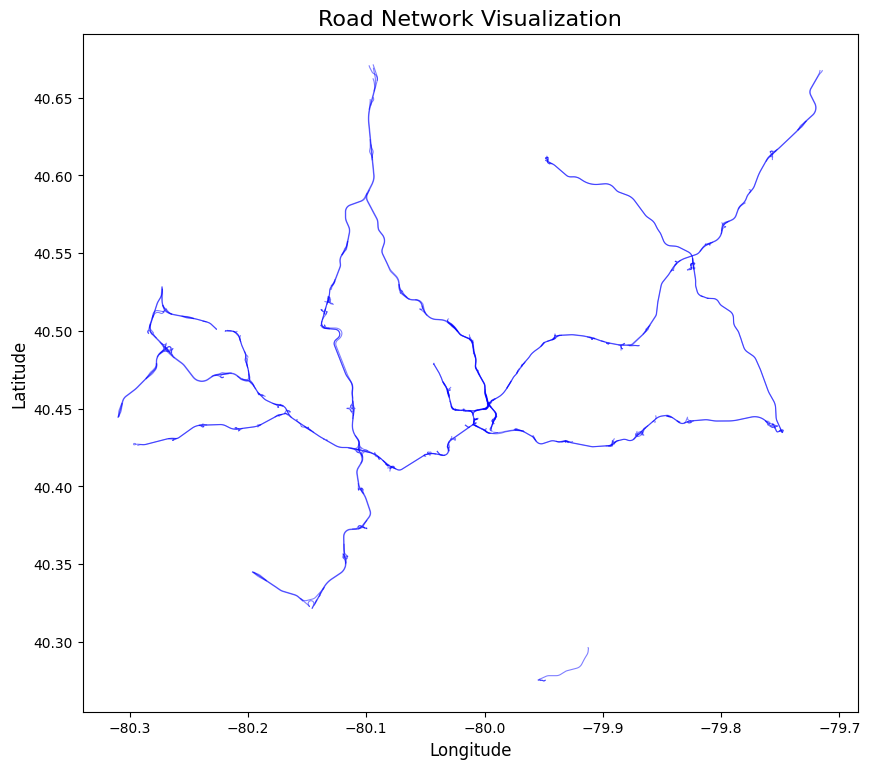

In [29]:
import matplotlib.pyplot as plt

# تنظیم اندازه نمودار
plt.figure(figsize=(10, 10))

# رسم هندسه‌ها (شامل خطوط جاده‌ها)
df.plot(ax=plt.gca(), color='blue', alpha=0.5, linewidth=0.8)

# افزودن عنوان و برچسب‌ها
plt.title('Road Network Visualization', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# نمایش گراف
plt.show()


In [30]:
df.to_csv('network.csv')

join kardan dadeh tasadofat ba shabakeh rahha

In [31]:
df['id'] = range(len(df))


In [32]:
import pandas as pd

df_accidents = pd.read_csv('accident_data_filtered.csv')

# حذف ستون اضافی در صورت وجود
if 'Unnamed: 0' in df_accidents.columns:
    df_accidents = df_accidents.drop(['Unnamed: 0'], axis=1)

# نمایش ابعاد داده‌ها
print(df_accidents.shape)

# نمایش نام ستون‌ها
print(df_accidents.columns)


(10370, 191)
Index(['Year', 'Month', 'Day_of_Week', 'Hour', '_id', 'CRASH_CRN', 'DISTRICT',
       'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY',
       ...
       'LANE_COUNT', 'RDWY_ORIENT', 'ROAD_OWNER', 'ROUTE', 'SPEED_LIMIT',
       'SEGMENT', 'OFFSET', 'STREET_NAME', 'TOT_INJ_COUNT', 'SCHOOL_BUS_UNIT'],
      dtype='object', length=191)


In [33]:
from shapely.geometry import Point

# ایجاد هندسه برای هر تصادف
df_accidents['geometry'] = df_accidents[['DEC_LAT', 'DEC_LONG']].apply(lambda h: Point(h[1], h[0]), axis=1)

# تبدیل به GeoDataFrame
gdf_acc = gpd.GeoDataFrame(df_accidents, geometry='geometry')


C:\Users\HP\AppData\Local\Temp\ipykernel_4992\339634166.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_accidents['geometry'] = df_accidents[['DEC_LAT', 'DEC_LONG']].apply(lambda h: Point(h[1], h[0]), axis=1)


In [34]:
# اگر CRS برای gdf_acc مشخص نیست، آن را تنظیم کنید
if gdf_acc.crs is None:
    gdf_acc.set_crs(epsg=4326, inplace=True)  # سیستم مختصات جغرافیایی

# تنظیم CRS برای جاده‌ها در صورت نیاز
if df.crs is None:
    df.set_crs(epsg=4326, inplace=True)

# تبدیل CRS داده‌ها به UTM (برای دقت بالاتر در محاسبه فاصله‌ها)
gdf_acc = gdf_acc.to_crs(epsg=32617)  # EPSG مربوط به UTM منطقه Allegheny
df = df.to_crs(epsg=32617)


In [35]:
# بررسی محدوده جاده‌ها و تصادفات
print("Accident Bounds:", gdf_acc.total_bounds)
print("Road Bounds:", df.total_bounds)


Accident Bounds: [ 500008.46095474 4428236.06463309  756099.64797028 4503004.43648389]
Road Bounds: [ 558532.6548867  4458798.26167241  608673.38685465 4502665.42318235]


In [36]:
# حالا از sjoin_nearest برای پیوستن داده‌ها استفاده کنید
dfc = gdf_acc.sjoin_nearest(df[['geometry', 'id']], how='left', distance_col='dist')

# نمایش ابعاد و ستون‌های داده‌های ترکیب‌شده
print(dfc.shape)
print(dfc.columns)


(10800, 197)
Index(['Year', 'Month', 'Day_of_Week', 'Hour', '_id', 'CRASH_CRN', 'DISTRICT',
       'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY',
       ...
       'OFFSET', 'STREET_NAME', 'TOT_INJ_COUNT', 'SCHOOL_BUS_UNIT', 'geometry',
       'u', 'v', 'key', 'id', 'dist'],
      dtype='object', length=197)


In [37]:
print(dfc['Day_of_Week'].value_counts())


Day_of_Week
6    1760
7    1597
4    1590
5    1507
3    1466
1    1443
2    1437
Name: count, dtype: int64


In [38]:
# بررسی آماری مقدار فاصله‌ها
print("Distance Statistics:")
print(dfc['dist'].describe())

# نمایش نمونه‌ای از داده‌ها
print(dfc[['geometry', 'dist']].head(10))

# بررسی تعداد مقادیر NaN در `id`
print("Number of NaN in id:", dfc['id'].isna().sum())


Distance Statistics:
count     10792.000000
mean       2565.991849
std        4913.940193
min           0.001726
25%         235.036232
50%        1590.090221
75%        3655.527875
max      156420.121673
Name: dist, dtype: float64
                         geometry         dist
0  POINT (592403.373 4473501.088)  2052.560871
1  POINT (601582.302 4485654.747)   128.958529
2  POINT (588622.161 4473899.517)  1827.294522
3  POINT (580428.383 4478314.309)  1900.280473
4  POINT (580089.527 4482240.585)  1323.174077
5  POINT (584007.417 4470726.888)  4561.419040
6  POINT (582533.017 4473563.587)  1370.056305
7   POINT (604337.092 4477077.17)   736.789650
8  POINT (597871.524 4465477.112)  6908.934437
9  POINT (580294.839 4482065.163)  1053.279372
Number of NaN in id: 8


In [39]:
dfc = dfc.rename(columns={'_id': 'id'})


In [40]:
print(dfc['dist'].head())  # بررسی مقدار فاصله‌ها
print(dfc['dist'].isna().sum())  # بررسی تعداد مقادیر NaN


0    2052.560871
1     128.958529
2    1827.294522
3    1900.280473
4    1323.174077
Name: dist, dtype: float64
8


In [41]:
dfc = dfc[dfc['dist'] < 501]

# نمایش اطلاعات نهایی
print(dfc.shape)
print(dfc.columns)


(3302, 197)
Index(['Year', 'Month', 'Day_of_Week', 'Hour', 'id', 'CRASH_CRN', 'DISTRICT',
       'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY',
       ...
       'OFFSET', 'STREET_NAME', 'TOT_INJ_COUNT', 'SCHOOL_BUS_UNIT', 'geometry',
       'u', 'v', 'key', 'id', 'dist'],
      dtype='object', length=197)


In [42]:
print(dfc.columns)  # بررسی نام تمام ستون‌ها


Index(['Year', 'Month', 'Day_of_Week', 'Hour', 'id', 'CRASH_CRN', 'DISTRICT',
       'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY',
       ...
       'OFFSET', 'STREET_NAME', 'TOT_INJ_COUNT', 'SCHOOL_BUS_UNIT', 'geometry',
       'u', 'v', 'key', 'id', 'dist'],
      dtype='object', length=197)


In [43]:
import pandas as pd

pd.set_option('display.max_columns', None)  # نمایش تمام ستون‌ها بدون محدودیت
print(dfc.columns.tolist())  # نمایش لیست تمام نام ستون‌ها


['Year', 'Month', 'Day_of_Week', 'Hour', 'id', 'CRASH_CRN', 'DISTRICT', 'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY', 'TIME_OF_DAY', 'ILLUMINATION', 'WEATHER', 'ROAD_CONDITION', 'COLLISION_TYPE', 'RELATION_TO_ROAD', 'INTERSECT_TYPE', 'TCD_TYPE', 'URBAN_RURAL', 'LOCATION_TYPE', 'SCH_BUS_IND', 'SCH_ZONE_IND', 'TOTAL_UNITS', 'PERSON_COUNT', 'VEHICLE_COUNT', 'AUTOMOBILE_COUNT', 'MOTORCYCLE_COUNT', 'BUS_COUNT', 'SMALL_TRUCK_COUNT', 'HEAVY_TRUCK_COUNT', 'SUV_COUNT', 'VAN_COUNT', 'BICYCLE_COUNT', 'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT', 'UNK_INJ_DEG_COUNT', 'UNK_INJ_PER_COUNT', 'UNBELTED_OCC_COUNT', 'UNB_DEATH_COUNT', 'UNB_MAJ_INJ_COUNT', 'BELTED_DEATH_COUNT', 'BELTED_MAJ_INJ_COUNT', 'MCYCLE_DEATH_COUNT', 'MCYCLE_MAJ_INJ_COUNT', 'BICYCLE_DEATH_COUNT', 'BICYCLE_MAJ_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT', 'PED_MAJ_INJ_COUNT', 'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL', 'DRIVER_COUNT_16YR', 'DRIVER_COUNT_17YR', 'DRIVER_COUNT_18YR', 'DRIVER_COUNT_19YR', '

In [44]:
dfc = dfc.loc[:, ~dfc.columns.duplicated()]


In [45]:
print(type(dfc['id']))
print(dfc[['id']].shape)


<class 'pandas.core.series.Series'>
(3302, 1)


In [46]:
# جدا کردن ستون‌های 'u', 'v', 'key' و 'geometry' قبل از groupby
dfc_extra = dfc[['id', 'u', 'v', 'key', 'geometry']].drop_duplicates()

# انجام groupby و agg
df_freq_model = dfc.groupby([
    'id', 'Year', 'Month', 'Day_of_Week', 'Hour','ILLUMINATION'
]).agg({
    'FATAL_COUNT': 'sum',
    'INJURY_COUNT': 'sum',
    'MAJ_INJ_COUNT': 'sum',
    'MOD_INJ_COUNT': 'sum',
    'MIN_INJ_COUNT': 'sum',
    'PED_COUNT': 'sum',
    'PED_DEATH_COUNT': 'sum',
    'PED_MAJ_INJ_COUNT': 'sum',
    'BICYCLE_COUNT': 'sum',
    'BICYCLE_DEATH_COUNT': 'sum',
    'BICYCLE_MAJ_INJ_COUNT': 'sum',
    'MOTORCYCLE_COUNT': 'sum',
    'MCYCLE_DEATH_COUNT': 'sum',
    'MCYCLE_MAJ_INJ_COUNT': 'sum',
    'COMM_VEH_COUNT': 'sum',
    'MAX_SEVERITY_LEVEL': 'sum',
    'PROPERTY_DAMAGE_ONLY': 'sum',
    'FATAL_OR_MAJ_INJ': 'sum',
    'INJURY': 'sum',
    'FATAL': 'sum',
    'dist': 'mean'  # محاسبه میانگین مسافت (DIST) برای هر گروه
}).reset_index()

# افزودن ستون‌های extra به مدل
df_freq_model = pd.merge(df_freq_model, dfc_extra, on='id', how='left')

# نمایش خروجی
print(df_freq_model.head())


       id  Year  Month  Day_of_Week  Hour  ILLUMINATION  FATAL_COUNT  \
0  228214  2023      1            1   1.0             3            0   
1  228229  2023      1            2  10.0             1            0   
2  228229  2023      1            2  10.0             1            0   
3  228230  2023      1            2  10.0             1            0   
4  228231  2023      1            2   9.0             1            0   

   INJURY_COUNT  MAJ_INJ_COUNT  MOD_INJ_COUNT  MIN_INJ_COUNT  PED_COUNT  \
0             0              0            0.0              0          0   
1             2              0            0.0              2          0   
2             2              0            0.0              2          0   
3             1              0            0.0              1          0   
4             0              0            0.0              0          0   

   PED_DEATH_COUNT  PED_MAJ_INJ_COUNT  BICYCLE_COUNT  BICYCLE_DEATH_COUNT  \
0                0                  0  

In [47]:
import pandas as pd

pd.set_option('display.max_columns', None)  # نمایش تمام ستون‌ها بدون محدودیت
print(df_freq_model.columns.tolist())  # نمایش لیست تمام نام ستون‌ها


['id', 'Year', 'Month', 'Day_of_Week', 'Hour', 'ILLUMINATION', 'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT', 'PED_MAJ_INJ_COUNT', 'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT', 'BICYCLE_MAJ_INJ_COUNT', 'MOTORCYCLE_COUNT', 'MCYCLE_DEATH_COUNT', 'MCYCLE_MAJ_INJ_COUNT', 'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL', 'PROPERTY_DAMAGE_ONLY', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'dist', 'u', 'v', 'key', 'geometry']


In [48]:
df_freq_model.to_csv('frequency.csv')

sakhtan bastar zamani ba estefadeh az dadeh haye abo o hava

In [49]:
import pandas as pd

# مسیر فایل ورودی CSV
file_path = r"open-meteo-40.46N79.97W236m (4).csv"

# خواندن داده‌ها (بدون حذف سطر)
df = pd.read_csv(file_path)

# تبدیل ستون "time" به فرمت datetime
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# استخراج ویژگی‌های زمانی
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df['Day'] = df['time'].dt.day
df['Day_of_Week'] = df['time'].dt.dayofweek  # 0=دوشنبه, 6=یکشنبه
df['Hour'] = df['time'].dt.hour

# حذف ستون "time" از داده‌ها
df = df.drop(columns=['time'])

# جابجایی ستون‌های مربوط به زمان به ابتدای جدول
time_columns = ['Year', 'Month', 'Day', 'Day_of_Week', 'Hour']
df = df[time_columns + [col for col in df.columns if col not in time_columns]]

# نمایش ۵ سطر اول برای بررسی
print(df.head())

# مسیر خروجی فایل جدید
output_path = "weather_data_with_time_features.csv"

# ذخیره داده‌های پردازش‌شده
df.to_csv(output_path, index=False)

print(f"✅ داده‌های پردازش‌شده در فایل ذخیره شد: {output_path}")


   Year  Month  Day  Day_of_Week  Hour  temperature_2m (°C)  \
0  2023      1    1            6     0                 10.4   
1  2023      1    1            6     1                 10.2   
2  2023      1    1            6     2                  9.5   
3  2023      1    1            6     3                  8.3   
4  2023      1    1            6     4                  7.6   

   relative_humidity_2m (%)  precipitation (mm)  rain (mm)  snowfall (cm)  \
0                        94                 0.3        0.3            0.0   
1                        96                 0.7        0.7            0.0   
2                        98                 0.1        0.1            0.0   
3                        98                 0.0        0.0            0.0   
4                        98                 0.0        0.0            0.0   

   snow_depth (m)  cloud_cover (%)  cloud_cover_low (%)  cloud_cover_mid (%)  \
0             0.0              100                   22                   82  

In [50]:
import pandas as pd

# مسیر فایل ورودی
file_path = "weather_data_with_time_features.csv"

# خواندن داده‌ها
dfweather = pd.read_csv(file_path)

# بررسی اینکه ستون "Hour" وجود دارد
if "Hour" not in dfweather.columns:
    raise KeyError("❌ ستون 'Hour' در فایل یافت نشد. لطفاً مطمئن شوید که قبلاً این ویژگی استخراج شده است.")

# تعریف بازه‌های زمانی یک ساعته
intervals = {h: f"{h:02d}:00 - {h:02d}:59" for h in range(24)}

# افزودن ستون بازه زمانی یک ساعته
dfweather["one-hour_intervals"] = dfweather["Hour"].map(intervals)

# مسیر ذخیره فایل جدید
output_weather_path = r"weather_data_with_one_hour_intervals.csv"

# ذخیره داده‌ها در فایل CSV
dfweather.to_csv(output_weather_path, index=False)

print(f"✅ داده‌های پردازش‌شده در فایل ذخیره شد: {output_weather_path}")


✅ داده‌های پردازش‌شده در فایل ذخیره شد: weather_data_with_one_hour_intervals.csv


In [51]:
print(dfc.columns)


Index(['Year', 'Month', 'Day_of_Week', 'Hour', 'id', 'CRASH_CRN', 'DISTRICT',
       'CRASH_COUNTY', 'MUNICIPALITY', 'POLICE_AGCY',
       ...
       'SEGMENT', 'OFFSET', 'STREET_NAME', 'TOT_INJ_COUNT', 'SCHOOL_BUS_UNIT',
       'geometry', 'u', 'v', 'key', 'dist'],
      dtype='object', length=196)


In [52]:
dfweather.describe(include='all')


,Year,Month,Day,Day_of_Week,Hour,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),snowfall (cm),snow_depth (m),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h),one-hour_intervals
count,8760.0,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,00:00 - 00:59
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,365
mean,2023.0,6.526027,15.720548,3.008219,11.500000,12.582295,70.849201,0.119064,0.116050,0.002118,0.002005,63.228767,28.275342,31.209817,37.607763,10.581393,18.496461,205.955137,208.654680,23.272683,NaN
std,0.0,3.448048,8.796749,2.003519,6.922582,8.889694,19.209322,0.517954,0.515923,0.029304,0.007406,42.255176,40.220280,40.003871,44.807106,5.352364,8.547405,92.170123,90.754941,11.283002,NaN
min,2023.0,1.000000,1.000000,0.000000,0.000000,-11.200000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,2.000000,1.000000,2.500000,NaN
25%,2023.0,4.000000,8.000000,1.000000,5.750000,5.300000,56.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,6.700000,12.300000,141.000000,145.000000,14.800000,NaN
50%,2023.0,7.000000,16.000000,3.000000,11.500000,12.700000,73.000000,0.000000,0.000000,0.000000,0.000000,93.000000,2.000000,6.000000,3.000000,9.700000,18.100000,222.000000,225.000000,21.200000,NaN
75%,2023.0,10.000000,23.000000,5.000000,17.250000,19.800000,88.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,69.000000,99.000000,13.600000,23.900000,277.000000,277.000000,30.200000,NaN


edgham bastar makani o zamani be ravesh cross

In [53]:
import pandas as pd


# خواندن داده‌ها
df = pd.read_csv("network.csv")
dfweather = pd.read_csv("weather_data_with_one_hour_intervals.csv")

In [54]:
df.describe(include='all')

,u,v,key,geometry,highway,name,lanes,bridge,oneway,tunnel,maxspeed
count,1.155000e+03,1.155000e+03,1155.0,1155,1155,338,1128,357,1155,19,427
unique,NaN,NaN,NaN,1155,2,21,16,1,2,1,18
top,NaN,NaN,NaN,"LINESTRING (-79.8966174 40.491953, -79.8965577...",motorway_link,Allegheny Valley Expressway,1,yes,True,yes,55 mph
freq,NaN,NaN,NaN,1,758,61,576,357,1131,19,204
mean,1.544439e+09,1.839936e+09,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.986145e+09,2.192191e+09,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.041917e+08,1.041917e+08,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,6.848440e+08,6.849077e+08,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,6.953957e+08,6.974964e+08,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.420355e+08,1.753679e+09,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
dfweather['Year'].value_counts()

Year
2023    8760
Name: count, dtype: int64

In [56]:

# اجرای merge فقط روی داده‌های فیلتر شده
dff = pd.merge(df, dfweather, how="cross")

print("dff shape:", dff.shape)


dff shape: (10117800, 32)


In [57]:
print(dff.columns)


Index(['u', 'v', 'key', 'geometry', 'highway', 'name', 'lanes', 'bridge',
       'oneway', 'tunnel', 'maxspeed', 'Year', 'Month', 'Day', 'Day_of_Week',
       'Hour', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'rain (mm)', 'snowfall (cm)', 'snow_depth (m)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'wind_speed_10m (km/h)',
       'wind_speed_100m (km/h)', 'wind_direction_10m (°)',
       'wind_direction_100m (°)', 'wind_gusts_10m (km/h)',
       'one-hour_intervals'],
      dtype='object')


In [58]:
print("وجود ستون dist:", 'dist' in dff.columns)
print("وجود ستون CRASH_CRN:", 'CRASH_CRN' in dff.columns)
print(dff.head())


وجود ستون dist: False
وجود ستون CRASH_CRN: False
           u          v  key  \
0  104191698  740727109    0   
1  104191698  740727109    0   
2  104191698  740727109    0   
3  104191698  740727109    0   
4  104191698  740727109    0   

                                            geometry        highway name  \
0  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
1  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
2  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
3  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
4  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   

  lanes bridge  oneway tunnel maxspeed  Year  Month  Day  Day_of_Week  Hour  \
0     1    NaN    True    NaN      NaN  2023      1    1            6     0   
1     1    NaN    True    NaN      NaN  2023      1    1            6     1   
2     1    NaN    True    NaN      NaN  2023      1    1        

In [59]:
print(dff.columns)


Index(['u', 'v', 'key', 'geometry', 'highway', 'name', 'lanes', 'bridge',
       'oneway', 'tunnel', 'maxspeed', 'Year', 'Month', 'Day', 'Day_of_Week',
       'Hour', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'rain (mm)', 'snowfall (cm)', 'snow_depth (m)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'wind_speed_10m (km/h)',
       'wind_speed_100m (km/h)', 'wind_direction_10m (°)',
       'wind_direction_100m (°)', 'wind_gusts_10m (km/h)',
       'one-hour_intervals'],
      dtype='object')


In [60]:
print(dff.isnull().sum())  # تعداد مقادیر خالی در هر ستون


u                                 0
v                                 0
key                               0
geometry                          0
highway                           0
name                        7156920
lanes                        236520
bridge                      6990480
oneway                            0
tunnel                      9951360
maxspeed                    6377280
Year                              0
Month                             0
Day                               0
Day_of_Week                       0
Hour                              0
temperature_2m (°C)               0
relative_humidity_2m (%)          0
precipitation (mm)                0
rain (mm)                         0
snowfall (cm)                     0
snow_depth (m)                    0
cloud_cover (%)                   0
cloud_cover_low (%)               0
cloud_cover_mid (%)               0
cloud_cover_high (%)              0
wind_speed_10m (km/h)             0
wind_speed_100m (km/h)      

In [61]:
# اضافه کردن ستون 'id' در ابتدا
dff.insert(0, 'id', range(1, len(dff) + 1))

# نمایش ۵ سطر اول دیتافریم اصلاح‌شده
print(dff.head())


   id          u          v  key  \
0   1  104191698  740727109    0   
1   2  104191698  740727109    0   
2   3  104191698  740727109    0   
3   4  104191698  740727109    0   
4   5  104191698  740727109    0   

                                            geometry        highway name  \
0  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
1  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
2  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
3  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
4  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   

  lanes bridge  oneway tunnel maxspeed  Year  Month  Day  Day_of_Week  Hour  \
0     1    NaN    True    NaN      NaN  2023      1    1            6     0   
1     1    NaN    True    NaN      NaN  2023      1    1            6     1   
2     1    NaN    True    NaN      NaN  2023      1    1            6     2   
3     1   

In [62]:
print(dff.columns)


Index(['id', 'u', 'v', 'key', 'geometry', 'highway', 'name', 'lanes', 'bridge',
       'oneway', 'tunnel', 'maxspeed', 'Year', 'Month', 'Day', 'Day_of_Week',
       'Hour', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'rain (mm)', 'snowfall (cm)', 'snow_depth (m)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'wind_speed_10m (km/h)',
       'wind_speed_100m (km/h)', 'wind_direction_10m (°)',
       'wind_direction_100m (°)', 'wind_gusts_10m (km/h)',
       'one-hour_intervals'],
      dtype='object')


In [63]:
print(dff['Day_of_Week'].value_counts())


Day_of_Week
6    1469160
0    1441440
1    1441440
2    1441440
3    1441440
4    1441440
5    1441440
Name: count, dtype: int64


In [64]:
print(df_freq_model.columns)


Index(['id', 'Year', 'Month', 'Day_of_Week', 'Hour', 'ILLUMINATION',
       'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT',
       'MIN_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT', 'PED_MAJ_INJ_COUNT',
       'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT', 'BICYCLE_MAJ_INJ_COUNT',
       'MOTORCYCLE_COUNT', 'MCYCLE_DEATH_COUNT', 'MCYCLE_MAJ_INJ_COUNT',
       'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL', 'PROPERTY_DAMAGE_ONLY',
       'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'dist', 'u', 'v', 'key',
       'geometry'],
      dtype='object')


In [65]:
df_freq_model.isnull().sum()


id                       0
Year                     0
Month                    0
Day_of_Week              0
Hour                     0
ILLUMINATION             0
FATAL_COUNT              0
INJURY_COUNT             0
MAJ_INJ_COUNT            0
MOD_INJ_COUNT            0
MIN_INJ_COUNT            0
PED_COUNT                0
PED_DEATH_COUNT          0
PED_MAJ_INJ_COUNT        0
BICYCLE_COUNT            0
BICYCLE_DEATH_COUNT      0
BICYCLE_MAJ_INJ_COUNT    0
MOTORCYCLE_COUNT         0
MCYCLE_DEATH_COUNT       0
MCYCLE_MAJ_INJ_COUNT     0
COMM_VEH_COUNT           0
MAX_SEVERITY_LEVEL       0
PROPERTY_DAMAGE_ONLY     0
FATAL_OR_MAJ_INJ         0
INJURY                   0
FATAL                    0
dist                     0
u                        0
v                        0
key                      0
geometry                 0
dtype: int64

In [66]:
# لیست ستون‌های کلیدی برای ادغام
common_keys = ['id', 'Year', 'Month', 'Day_of_Week', 'Hour']

In [67]:
print("قبل از پردازش:")
print(dff['Day_of_Week'].value_counts(dropna=False))  # نمایش تمام مقادیر یکتا، حتی NaN  
print(dff['Day_of_Week'].dtype)  # بررسی نوع داده


قبل از پردازش:
Day_of_Week
6    1469160
0    1441440
1    1441440
2    1441440
3    1441440
4    1441440
5    1441440
Name: count, dtype: int64
int64


In [68]:
import pandas as pd

def standardize_columns(dff, df_freq_model):
    """
    این تابع نوع داده‌های کلیدی مورد نیاز برای merge را در هر دو دیتافریم یکسان‌سازی می‌کند.
    """

    # اگر مقدارها قبلاً عددی هستند، نیازی به map نیست!
    if 'Day_of_Week' in dff.columns:
        print("مقدارهای اولیه در dff['Day_of_Week']:", dff['Day_of_Week'].unique())

        # اطمینان از اینکه ستون عددی است و مقدارهای نامعتبر حذف شده‌اند
        dff.loc[:, 'Day_of_Week'] = pd.to_numeric(dff['Day_of_Week'], errors='coerce')

        # جایگزینی مقدارهای نامشخص (NaN) با 0 و تبدیل به int
        dff.loc[:, 'Day_of_Week'] = dff['Day_of_Week'].fillna(0).astype(int)

    if 'Day_of_Week' in df_freq_model.columns:
        df_freq_model.loc[:, 'Day_of_Week'] = pd.to_numeric(df_freq_model['Day_of_Week'], errors='coerce').fillna(0).astype(int)

    return dff, df_freq_model

# اجرای تابع روی دو دیتافریم
dff, df_freq_model = standardize_columns(dff, df_freq_model)

# بررسی مقدارهای جدید
print("بعد از پردازش:")
print(dff['Day_of_Week'].value_counts(dropna=False))


مقدارهای اولیه در dff['Day_of_Week']: [6 0 1 2 3 4 5]
بعد از پردازش:
Day_of_Week
6    1469160
0    1441440
1    1441440
2    1441440
3    1441440
4    1441440
5    1441440
Name: count, dtype: int64


In [69]:
import pandas as pd

def standardize_columns(dff, df_freq_model):
    """
    این تابع نوع داده‌های کلیدی مورد نیاز برای merge را در هر دو دیتافریم یکسان‌سازی می‌کند.
    """

    # اطمینان از اینکه ستون‌های کلیدی که برای merge استفاده می‌شوند، در هر دو دیتافریم هستند
    key_columns = ['id', 'name', 'Year', 'Month', 'Day_of_Week', 'Hour']
    
    # تبدیل ستون‌های عددی به int، اما بررسی قبل از تغییر مقدار
    for col in ['id', 'Year', 'Month', 'Hour']:
        if col in dff.columns:
            dff[col] = pd.to_numeric(dff[col], errors='coerce').fillna(0).astype(int)
        if col in df_freq_model.columns:
            df_freq_model[col] = pd.to_numeric(df_freq_model[col], errors='coerce').fillna(0).astype(int)

    # تبدیل 'Day_of_Week' فقط اگر مقادیر آن از قبل صحیح نباشند
    if 'Day_of_Week' in dff.columns:
        unique_values = dff['Day_of_Week'].dropna().unique()

        if all(isinstance(x, (int, float)) for x in unique_values):
            dff['Day_of_Week'] = dff['Day_of_Week'].astype(int)
        else:
            # اگر مقادیر متنی هستند، آنها را به نام روزهای هفته نگاشت کنیم
            days_map = {
                'Saturday': 6, 'Sunday': 7, 'Monday': 1, 'Tuesday': 2,
                'Wednesday': 3, 'Thursday': 4, 'Friday': 5
            }
    


In [70]:
print(dff['Day_of_Week'].value_counts())


Day_of_Week
6    1469160
0    1441440
1    1441440
2    1441440
3    1441440
4    1441440
5    1441440
Name: count, dtype: int64


In [71]:
print(df_freq_model['Day_of_Week'].value_counts())


Day_of_Week
6    522
7    497
5    493
4    487
1    439
2    439
3    425
Name: count, dtype: int64


In [72]:
print(df_freq_model['id'].value_counts())


id
232575    2
232143    2
228485    2
233503    2
229537    2
         ..
228379    1
228380    1
228385    1
228391    1
228256    1
Name: count, Length: 3242, dtype: int64


In [73]:
print(dff['id'].value_counts())


id
10117800    1
1           1
2           1
3           1
4           1
           ..
12          1
13          1
14          1
15          1
16          1
Name: count, Length: 10117800, dtype: int64


In [74]:
print(df_freq_model[['id', 'Year', 'Month', 'Day_of_Week', 'Hour']].nunique())
print(dff[['id', 'Year', 'Month', 'Day_of_Week', 'Hour']].nunique())


id             3242
Year              1
Month            12
Day_of_Week       7
Hour             25
dtype: int64
id             10117800
Year                  1
Month                12
Day_of_Week           7
Hour                 24
dtype: int64


In [75]:
print(sorted(df_freq_model['Hour'].unique()))  # نمایش ساعت‌های موجود


[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(99.0)]


In [76]:
df_freq_model = df_freq_model[df_freq_model['Hour'] < 24]  # حذف ساعت‌های اشتباه


In [77]:
print(sorted(df_freq_model['Hour'].unique()))  # نمایش ساعت‌های موجود


[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0)]


In [78]:
# تبدیل نوع داده‌ها به int در هر دو دیتافریم
dff['Year'] = dff['Year'].astype(int)
dff['Month'] = dff['Month'].astype(int)
dff['Day_of_Week'] = dff['Day_of_Week'].astype(int)
dff['Hour'] = dff['Hour'].astype(int)

df_freq_model['Year'] = df_freq_model['Year'].astype(int)
df_freq_model['Month'] = df_freq_model['Month'].astype(int)
df_freq_model['Day_of_Week'] = df_freq_model['Day_of_Week'].astype(int)
df_freq_model['Hour'] = df_freq_model['Hour'].astype(int)


In [79]:
print(dff.columns)  
print(df_freq_model.columns)


Index(['id', 'u', 'v', 'key', 'geometry', 'highway', 'name', 'lanes', 'bridge',
       'oneway', 'tunnel', 'maxspeed', 'Year', 'Month', 'Day', 'Day_of_Week',
       'Hour', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'precipitation (mm)', 'rain (mm)', 'snowfall (cm)', 'snow_depth (m)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'wind_speed_10m (km/h)',
       'wind_speed_100m (km/h)', 'wind_direction_10m (°)',
       'wind_direction_100m (°)', 'wind_gusts_10m (km/h)',
       'one-hour_intervals'],
      dtype='object')
Index(['id', 'Year', 'Month', 'Day_of_Week', 'Hour', 'ILLUMINATION',
       'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT',
       'MIN_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT', 'PED_MAJ_INJ_COUNT',
       'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT', 'BICYCLE_MAJ_INJ_COUNT',
       'MOTORCYCLE_COUNT', 'MCYCLE_DEATH_COUNT', 'MCYCLE_MAJ_INJ_COUNT',
       'COMM_VEH_COUNT', 'MAX_SEVERITY

In [80]:
df_freq_model["ACCIDENT_COUNT"] = df_freq_model[["PROPERTY_DAMAGE_ONLY", "FATAL_OR_MAJ_INJ", "INJURY", "FATAL"]].sum(axis=1)


In [81]:
import pandas as pd

# اگر داده‌های تصادفات فقط سال و ماه دارند، پس سطح زمانی داده‌های مکانی-زمانی را همسان کنیم
if 'Day_of_Week' not in df_freq_model.columns:
    dff['YearMonth'] = dff['Year'].astype(str) + '-' + dff['Month'].astype(str)
    df_freq_model['YearMonth'] = df_freq_model['Year'].astype(str) + '-' + df_freq_model['Month'].astype(str)

    merge_keys = ['YearMonth']
else:
    merge_keys = ['Year', 'Month', 'Day_of_Week', 'Hour']

# ادغام بر اساس مکان (`u`, `v`, `key`) و زمان
df_merged = pd.merge(
    dff,  # داده‌های آب و هوا + شبکه راه‌ها
    df_freq_model,  # داده‌های تصادفات
    how='left',  
    on=merge_keys + ['u', 'v', 'key']  # اضافه کردن موقعیت جغرافیایی
)

# جایگذاری مقدار صفر برای ستون‌های تصادف که مقدار NaN دارند
accident_columns = [
    'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 
    'MIN_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT', 'PED_MAJ_INJ_COUNT', 
    'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT', 'BICYCLE_MAJ_INJ_COUNT', 
    'MOTORCYCLE_COUNT', 'MCYCLE_DEATH_COUNT', 'MCYCLE_MAJ_INJ_COUNT', 
    'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL', 'PROPERTY_DAMAGE_ONLY', 
    'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL','ILLUMINATION'
]

df_merged[accident_columns] = df_merged[accident_columns].fillna(0)

# بررسی مقدار NaN در دیگر ستون‌ها
print(df_merged.isnull().sum())

# بررسی تعداد یکتای تصادفات قبل و بعد از Merge
print("Unique Accidents in df_freq_model:", df_freq_model['ACCIDENT_COUNT'].sum())
print("Unique Accidents in df_merged:", df_merged['ACCIDENT_COUNT'].sum())

# نمایش نمونه‌ای از داده‌های نهایی
print(df_merged.head())


id_x                               0
u                                  0
v                                  0
key                                0
geometry_x                         0
highway                            0
name                         7156965
lanes                         236520
bridge                       6990517
oneway                             0
tunnel                       9951481
maxspeed                     6377307
Year                               0
Month                              0
Day                                0
Day_of_Week                        0
Hour                               0
temperature_2m (°C)                0
relative_humidity_2m (%)           0
precipitation (mm)                 0
rain (mm)                          0
snowfall (cm)                      0
snow_depth (m)                     0
cloud_cover (%)                    0
cloud_cover_low (%)                0
cloud_cover_mid (%)                0
cloud_cover_high (%)               0
w

In [82]:
print(df_merged.shape)  # بررسی تعداد سطرها و ستون‌ها
print(df_merged.isnull().sum())  # بررسی تعداد مقادیر Null در هر ستون
print(df_merged.head())  # نمایش چند سطر اول دیتافریم


(10117929, 58)
id_x                               0
u                                  0
v                                  0
key                                0
geometry_x                         0
highway                            0
name                         7156965
lanes                         236520
bridge                       6990517
oneway                             0
tunnel                       9951481
maxspeed                     6377307
Year                               0
Month                              0
Day                                0
Day_of_Week                        0
Hour                               0
temperature_2m (°C)                0
relative_humidity_2m (%)           0
precipitation (mm)                 0
rain (mm)                          0
snowfall (cm)                      0
snow_depth (m)                     0
cloud_cover (%)                    0
cloud_cover_low (%)                0
cloud_cover_mid (%)                0
cloud_cover_high (%)   

In [83]:
print(sorted(df_merged['Hour'].unique()))  # نمایش ساعت‌های موجود


[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


In [84]:
df_merged.isnull().sum()


id_x                               0
u                                  0
v                                  0
key                                0
geometry_x                         0
highway                            0
name                         7156965
lanes                         236520
bridge                       6990517
oneway                             0
tunnel                       9951481
maxspeed                     6377307
Year                               0
Month                              0
Day                                0
Day_of_Week                        0
Hour                               0
temperature_2m (°C)                0
relative_humidity_2m (%)           0
precipitation (mm)                 0
rain (mm)                          0
snowfall (cm)                      0
snow_depth (m)                     0
cloud_cover (%)                    0
cloud_cover_low (%)                0
cloud_cover_mid (%)                0
cloud_cover_high (%)               0
w

In [85]:
print(df_merged[['FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT']].sum())


FATAL_COUNT        78.0
INJURY_COUNT     6385.0
MAJ_INJ_COUNT     478.0
MOD_INJ_COUNT       0.0
MIN_INJ_COUNT    3195.0
dtype: float64


In [86]:
import pandas as pd

# فرض بر این است که دیتافریم شما df نام دارد
df_merged.columns = df_merged.columns.str.replace(r"\s*\(.*?\)", "", regex=True)

# نمایش نام ستون‌ها پس از حذف واحدها
print(df_merged.columns)


Index(['id_x', 'u', 'v', 'key', 'geometry_x', 'highway', 'name', 'lanes',
       'bridge', 'oneway', 'tunnel', 'maxspeed', 'Year', 'Month', 'Day',
       'Day_of_Week', 'Hour', 'temperature_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'snow_depth', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'one-hour_intervals', 'id_y',
       'ILLUMINATION', 'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT',
       'MOD_INJ_COUNT', 'MIN_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT',
       'PED_MAJ_INJ_COUNT', 'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT',
       'BICYCLE_MAJ_INJ_COUNT', 'MOTORCYCLE_COUNT', 'MCYCLE_DEATH_COUNT',
       'MCYCLE_MAJ_INJ_COUNT', 'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL',
       'PROPERTY_DAMAGE_ONLY', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'dist',
       'geometry_y', 'ACCIDENT_COUNT'],
      dtype='object')


In [87]:
print(df_merged.dtypes)


id_x                        int64
u                           int64
v                           int64
key                         int64
geometry_x                 object
highway                    object
name                       object
lanes                      object
bridge                     object
oneway                       bool
tunnel                     object
maxspeed                   object
Year                        int64
Month                       int64
Day                         int64
Day_of_Week                 int64
Hour                        int64
temperature_2m            float64
relative_humidity_2m        int64
precipitation             float64
rain                      float64
snowfall                  float64
snow_depth                float64
cloud_cover                 int64
cloud_cover_low             int64
cloud_cover_mid             int64
cloud_cover_high            int64
wind_speed_10m            float64
wind_speed_100m           float64
wind_direction

In [88]:
df_merged.describe(include="all")


,id_x,u,v,key,geometry_x,highway,name,lanes,bridge,oneway,tunnel,maxspeed,Year,Month,Day,Day_of_Week,Hour,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,snow_depth,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,one-hour_intervals,id_y,ILLUMINATION,FATAL_COUNT,INJURY_COUNT,MAJ_INJ_COUNT,MOD_INJ_COUNT,MIN_INJ_COUNT,PED_COUNT,PED_DEATH_COUNT,PED_MAJ_INJ_COUNT,BICYCLE_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_MAJ_INJ_COUNT,MOTORCYCLE_COUNT,MCYCLE_DEATH_COUNT,MCYCLE_MAJ_INJ_COUNT,COMM_VEH_COUNT,MAX_SEVERITY_LEVEL,PROPERTY_DAMAGE_ONLY,FATAL_OR_MAJ_INJ,INJURY,FATAL,dist,geometry_y,ACCIDENT_COUNT
count,1.011793e+07,1.011793e+07,1.011793e+07,10117929.0,10117929,10117929,2960964,9881409,3127412,10117929,166448,3740622,10117929.0,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,10117929,12107.000000,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,10117929.0,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,1.011793e+07,12107.000000,12107,12107.000000
unique,NaN,NaN,NaN,NaN,1155,2,21,16,1,2,1,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2355,NaN
top,NaN,NaN,NaN,NaN,"LINESTRING (-79.7627826 40.442403, -79.7630599...",motorway_link,Allegheny Valley Expressway,1,yes,True,yes,55 mph,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,07:00 - 07:59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (576464.1448211753 4469536.138701879),NaN
freq,NaN,NaN,NaN,NaN,8769,6640107,534365,5045760,3127412,9907689,166448,1787112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,421593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57,NaN
mean,5.058922e+06,1.544456e+09,1.839926e+09,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,6.526021e+00,1.572055e+01,3.008229e+00,1.150002e+01,1.258227e+01,7.084919e+01,1.190635e-01,1.160499e-01,2.117574e-03,2.004584e-03,6.322889e+01,2.827537e+01,3.120988e+01,3.760784e+01,1.058140e+01,1.849648e+01,2.059552e+02,2.086548e+02,2.327271e+01,NaN,233494.761460,2.184439e-03,7.709088e-06,6.310580e-04,4.724287e-05,0.0,3.157761e-04,3.123169e-05,1.680186e-06,6.226571e-06,1.106946e-05,3.953378e-07,3.953378e-07,2.777248e-05,1.186013e-06,8.796267e-06,1.297696e-04,2.578097e-03,6.860100e-04,4.447550e-05,4.897247e-04,7.214915e-06,97.791004,NaN,1.025770
std,2.920768e+06,1.985296e+09,2.191235e+09,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.447862e+00,8.796246e+00,2.003404e+00,6.922187e+00,8.889189e+00,1.920822e+01,5.179229e-01,5.158919e-01,2.930188e-02,7.405441e-03,4.225274e+01,4.021800e+01,4.000159e+01,4.480458e+01,5.352060e+00,8.546917e+00,9.216477e+01,9.074967e+01,1.128237e+01,NaN,3056.162505,7.429987e-02,2.949131e-03,3.349133e-02,9.514733e-03,0.0,2.260909e-02,6.240177e-03,1.296219e-03,2.864127e-03,3.746248e-03,6.287589e-04,6.287589e-04,5.650023e-03,1.089042e-03,3.341888e-03,1.304894e-02,1.302411e-01,2.679472e-02,7.182591e-03,2.315459e-02,2.686050e-03,140.997007,NaN,0.379114
min,1.000000e+00,1.041917e+08,1.041917e+08,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.120000e+01,1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e-01,2.000000e+00,1.000000e+00,2.500000e+00,NaN,228214.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0000

In [89]:
print(df_merged.shape)
print(df_merged.columns)


(10117929, 58)
Index(['id_x', 'u', 'v', 'key', 'geometry_x', 'highway', 'name', 'lanes',
       'bridge', 'oneway', 'tunnel', 'maxspeed', 'Year', 'Month', 'Day',
       'Day_of_Week', 'Hour', 'temperature_2m', 'relative_humidity_2m',
       'precipitation', 'rain', 'snowfall', 'snow_depth', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'one-hour_intervals', 'id_y',
       'ILLUMINATION', 'FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT',
       'MOD_INJ_COUNT', 'MIN_INJ_COUNT', 'PED_COUNT', 'PED_DEATH_COUNT',
       'PED_MAJ_INJ_COUNT', 'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT',
       'BICYCLE_MAJ_INJ_COUNT', 'MOTORCYCLE_COUNT', 'MCYCLE_DEATH_COUNT',
       'MCYCLE_MAJ_INJ_COUNT', 'COMM_VEH_COUNT', 'MAX_SEVERITY_LEVEL',
       'PROPERTY_DAMAGE_ONLY', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'dist',
       'geometry_y', 'ACCIDENT_COUNT'],
      dty

In [90]:
# محاسبه تعداد تصادفات در هر بازه زمانی
daily_accidents = df_merged.groupby(['Year', 'Month', 'Day']).size().reset_index(name='Crash_Count')
monthly_accidents = df_merged.groupby(['Year', 'Month']).size().reset_index(name='Crash_Count')
yearly_accidents = df_merged.groupby(['Year']).size().reset_index(name='Crash_Count')

# محاسبه آمار توصیفی
stats = {
    "daily": daily_accidents['Crash_Count'].describe(),
    "monthly": monthly_accidents['Crash_Count'].describe(),
    "yearly": yearly_accidents['Crash_Count'].describe()
}

# نمایش نتایج
for period, stat in stats.items():
    print(f"\nDescriptive Statistics for {period}:")
    print(stat)



Descriptive Statistics for daily:
count      365.000000
mean     27720.353425
std          0.709837
min      27720.000000
25%      27720.000000
50%      27720.000000
75%      27720.000000
max      27723.000000
Name: Crash_Count, dtype: float64

Descriptive Statistics for monthly:
count        12.000000
mean     843160.750000
std       24959.882055
min      776168.000000
25%      831607.750000
50%      859326.500000
75%      859332.750000
max      859348.000000
Name: Crash_Count, dtype: float64

Descriptive Statistics for yearly:
count           1.0
mean     10117929.0
std             NaN
min      10117929.0
25%      10117929.0
50%      10117929.0
75%      10117929.0
max      10117929.0
Name: Crash_Count, dtype: float64


In [91]:
print(df_merged[['FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT']].sum())


FATAL_COUNT        78.0
INJURY_COUNT     6385.0
MAJ_INJ_COUNT     478.0
MOD_INJ_COUNT       0.0
MIN_INJ_COUNT    3195.0
dtype: float64


In [92]:
print(df_freq_model[['FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT']].sum())


FATAL_COUNT        21.0
INJURY_COUNT     1690.0
MAJ_INJ_COUNT     124.0
MOD_INJ_COUNT       0.0
MIN_INJ_COUNT     861.0
dtype: float64


In [93]:
print("df_freq_model:", df_freq_model.shape)
print("df_merged:", df_merged.shape)
print("dff:",dff.shape)

df_freq_model: (3289, 32)
df_merged: (10117929, 58)
dff: (10117800, 33)


In [94]:
print(df_merged.head())  # نمایش چند سطر اول دیتافریم


   id_x          u          v  key  \
0     1  104191698  740727109    0   
1     2  104191698  740727109    0   
2     3  104191698  740727109    0   
3     4  104191698  740727109    0   
4     5  104191698  740727109    0   

                                          geometry_x        highway name  \
0  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
1  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
2  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
3  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   
4  LINESTRING (-79.8616003 40.5011141, -79.861533...  motorway_link  NaN   

  lanes bridge  oneway tunnel maxspeed  Year  Month  Day  Day_of_Week  Hour  \
0     1    NaN    True    NaN      NaN  2023      1    1            6     0   
1     1    NaN    True    NaN      NaN  2023      1    1            6     1   
2     1    NaN    True    NaN      NaN  2023      1    1            6     2  

In [95]:
print(df_merged[['FATAL_COUNT', 'INJURY_COUNT', 'MAJ_INJ_COUNT', 'MOD_INJ_COUNT', 'MIN_INJ_COUNT']].sum())


FATAL_COUNT        78.0
INJURY_COUNT     6385.0
MAJ_INJ_COUNT     478.0
MOD_INJ_COUNT       0.0
MIN_INJ_COUNT    3195.0
dtype: float64


In [96]:
import numpy as np

# بررسی رابطه دما و تصادفات
df_merged['temperature_bins'] = pd.qcut(df_merged['temperature_2m'], q=4, labels=['Cold', 'Cool', 'Warm', 'Hot'])
temp_analysis = df_merged.groupby('temperature_bins').size()

# بررسی رابطه تعداد خطوط و تصادفات
lanes_analysis = df_merged.groupby('lanes').size()

# بررسی رابطه سرعت مجاز و تصادفات
speed_analysis = df_merged.groupby('maxspeed').size()

print("Crash Count by Temperature Categories:")
print(temp_analysis)

print("\nCrash Count by Number of Lanes:")
print(lanes_analysis)

print("\nCrash Count by Speed Limit:")
print(speed_analysis)


C:\Users\HP\AppData\Local\Temp\ipykernel_4992\2815506278.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_analysis = df_merged.groupby('temperature_bins').size()


Crash Count by Temperature Categories:
temperature_bins
Cold    2547975
Cool    2543350
Warm    2502901
Hot     2523703
dtype: int64

Crash Count by Number of Lanes:
lanes
1                            5045760
2                            2058614
3                             762157
4                              78844
['1', '2']                    700813
['1', '3', '2']                26284
['1', '3']                     43800
['2', '3']                    324155
['3', '2']                    438009
['4', '1', '2']                26280
['4', '2', '3']                35040
['4', '2']                      8760
['4', '3', '2']                17520
['4', '3']                    297853
['4', '5', '3']                 8760
['7', '5', '3', '4', '6']       8760
dtype: int64

Crash Count by Speed Limit:
maxspeed
15 mph                     8760
20 mph                    43800
25 mph                    43800
30 mph                   113880
35 mph                   192720
40 mph                   

In [97]:
print(df_merged.isna().sum())


id_x                            0
u                               0
v                               0
key                             0
geometry_x                      0
highway                         0
name                      7156965
lanes                      236520
bridge                    6990517
oneway                          0
tunnel                    9951481
maxspeed                  6377307
Year                            0
Month                           0
Day                             0
Day_of_Week                     0
Hour                            0
temperature_2m                  0
relative_humidity_2m            0
precipitation                   0
rain                            0
snowfall                        0
snow_depth                      0
cloud_cover                     0
cloud_cover_low                 0
cloud_cover_mid                 0
cloud_cover_high                0
wind_speed_10m                  0
wind_speed_100m                 0
wind_direction

In [98]:
print(df_merged.shape)  # بررسی تعداد سطرها و ستون‌ها
print(df_merged.isnull().sum())  # بررسی تعداد مقادیر Null در هر ستون
print(df_merged.head())  # نمایش چند سطر اول دیتافریم


(10117929, 59)
id_x                            0
u                               0
v                               0
key                             0
geometry_x                      0
highway                         0
name                      7156965
lanes                      236520
bridge                    6990517
oneway                          0
tunnel                    9951481
maxspeed                  6377307
Year                            0
Month                           0
Day                             0
Day_of_Week                     0
Hour                            0
temperature_2m                  0
relative_humidity_2m            0
precipitation                   0
rain                            0
snowfall                        0
snow_depth                      0
cloud_cover                     0
cloud_cover_low                 0
cloud_cover_mid                 0
cloud_cover_high                0
wind_speed_10m                  0
wind_speed_100m                 0

In [99]:
import pandas as pd
import numpy as np

def extract_maxspeed(value):
    if isinstance(value, str):
        speeds = [int(s.split()[0]) for s in value.replace('[', '').replace(']', '').replace("'", "").split(', ')]
        return max(speeds)  # انتخاب بیشترین مقدار سرعت
    elif isinstance(value, (int, float)):  
        return value  # اگر مقدار از قبل عددی است، همان را برگردان
    return np.nan  # در غیر این صورت مقدار NaN برگردان

df_merged['maxspeed'] = df_merged['maxspeed'].apply(extract_maxspeed)

# بررسی نتیجه
print(df_merged['maxspeed'].unique())
print(df_merged['maxspeed'].dtype)  # باید از نوع عددی (int یا float) باشد


[nan 55. 65. 50. 70. 40. 25. 35. 45. 30.  5. 20. 15.]
float64


In [100]:
import ast

def extract_max_lanes(value):
    if isinstance(value, str) and value.startswith("["):  # بررسی اینکه مقدار، لیست رشته‌ای است
        try:
            value = ast.literal_eval(value)  # تبدیل رشته به لیست واقعی
            return max(map(int, value))  # یافتن بیشینه مقدار عددی
        except (ValueError, SyntaxError):
            return np.nan  # مقدار نامعتبر را به NaN تبدیل می‌کنیم
    return pd.to_numeric(value, errors='coerce')  # تبدیل مقادیر عادی به عددی

df_merged['lanes'] = df_merged['lanes'].apply(extract_max_lanes)
df_merged['lanes'] = df_merged['lanes'].fillna(0)


In [101]:
df_merged["ACCIDENT_COUNT"] = df_merged[["PROPERTY_DAMAGE_ONLY", "FATAL_OR_MAJ_INJ", "INJURY", "FATAL"]].sum(axis=1)


In [102]:
print(df_merged[['ACCIDENT_COUNT']].sum())


ACCIDENT_COUNT    12419.0
dtype: float64


sakhtan modelhaye tamrin dar do halat
1:faghat parametrhaye tasadofat
2:parametrhaye makani o ab o havaii

In [103]:
import pandas as pd
import statsmodels.api as sm
from shapely.geometry import Point
import pickle  # برای ذخیره‌سازی مدل

# ✅ 2. حذف مقادیر خالی
df = df_merged.dropna(subset=['ACCIDENT_COUNT'])

# ✅ 3. تعریف متغیر مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'geometry_y', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']]
y = df['ACCIDENT_COUNT']

# ✅ 4. استخراج مختصات طول و عرض جغرافیایی از هندسه (geometry_y)
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else None)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else None)

# ✅ 5. حذف رکوردهای NaN (در صورت نیاز)
df = df.dropna(subset=['LAT', 'LONG'])

# ✅ 6. تعریف متغیرهای مستقل و وابسته با استفاده از ستون‌های جدید
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']]
y = df['ACCIDENT_COUNT']

# ✅ 7. تبدیل همه‌ی داده‌ها به عدد
# تبدیل مقادیر متنی به کد عددی
for col in X.select_dtypes(include=['object']).columns:
    X[col], _ = X[col].factorize()

# تبدیل به float
X = X.astype(float)
y = y.astype(float)

# ✅ 8. حذف رکوردهای NaN
X = X.dropna()
y = y.dropna()

# ✅ 9. اضافه کردن Constant
X = sm.add_constant(X)

# ✅ 10. تعریف و برازش مدل پواسون
model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# ✅ 11. نمایش خلاصه مدل
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         ACCIDENT_COUNT   No. Observations:                12107
Model:                            GLM   Df Residuals:                    12100
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12243.
Date:                Thu, 20 Mar 2025   Deviance:                       905.35
Time:                        21:32:52   Pearson chi2:                     824.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08358
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -3.8625      6

In [104]:
import pandas as pd
import statsmodels.api as sm
from shapely.geometry import Point

# ✅ 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT'])

# ✅ 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else None)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else None)

# ✅ 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# ✅ 4. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']]
y = df['ACCIDENT_COUNT']

# ✅ 5. تبدیل مقادیر متنی به عددی (در صورت وجود)
for col in X.select_dtypes(include=['object']).columns:
    X[col], _ = X[col].factorize()

# ✅ 6. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# ✅ 7. حذف مقادیر خالی
X = X.dropna()
y = y.dropna()

# ✅ 8. اضافه کردن مقدار ثابت (Intercept)
X = sm.add_constant(X)

# ✅ 9. برازش مدل رگرسیون منفی دوجمله‌ای
model_nb = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()

# ✅ 10. نمایش نتایج مدل
print(model_nb.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         ACCIDENT_COUNT   No. Observations:                12107
Model:                            GLM   Df Residuals:                    12100
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16725.
Date:                Thu, 20 Mar 2025   Deviance:                       591.44
Time:                        21:32:59   Pearson chi2:                     526.
No. Iterations:                     7   Pseudo R-squ. (CS):            0.04420
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -4.3382      8

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [105]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.discrete.count_model as cm
from shapely.geometry import Point

# ✅ 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT'])

# ✅ 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else None)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else None)

# ✅ 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# ✅ 4. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']]
y = df['ACCIDENT_COUNT']

# ✅ 5. تبدیل مقادیر متنی به عددی (در صورت وجود)
for col in X.select_dtypes(include=['object']).columns:
    X[col], _ = X[col].factorize()

# ✅ 6. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# ✅ 7. حذف مقادیر خالی
X = X.dropna()
y = y.dropna()

# ✅ 8. اضافه کردن مقدار ثابت (Intercept)
X = sm.add_constant(X)

# ✅ 9. برازش مدل ZIP
model_zip = cm.ZeroInflatedPoisson(y, X, inflation='logit').fit()

# ✅ 10. نمایش خلاصه مدل
print(model_zip.summary())


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1074: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:835: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1567: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + exposure + offset)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1568: RuntimeWarning: invalid value encountered in multiply
  return -np.dot(L*X.T, X

         Current function value: inf
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:          ACCIDENT_COUNT   No. Observations:                12107
Model:             ZeroInflatedPoisson   Df Residuals:                    12100
Method:                            MLE   Df Model:                            6
Date:                 Thu, 20 Mar 2025   Pseudo R-squ.:                    -inf
Time:                         21:33:08   Log-Likelihood:                   -inf
converged:                       False   LL-Null:                       -12771.
Covariance Type:             nonrobust   LLR p-value:                     1.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const          0.1000        nan        nan        n

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


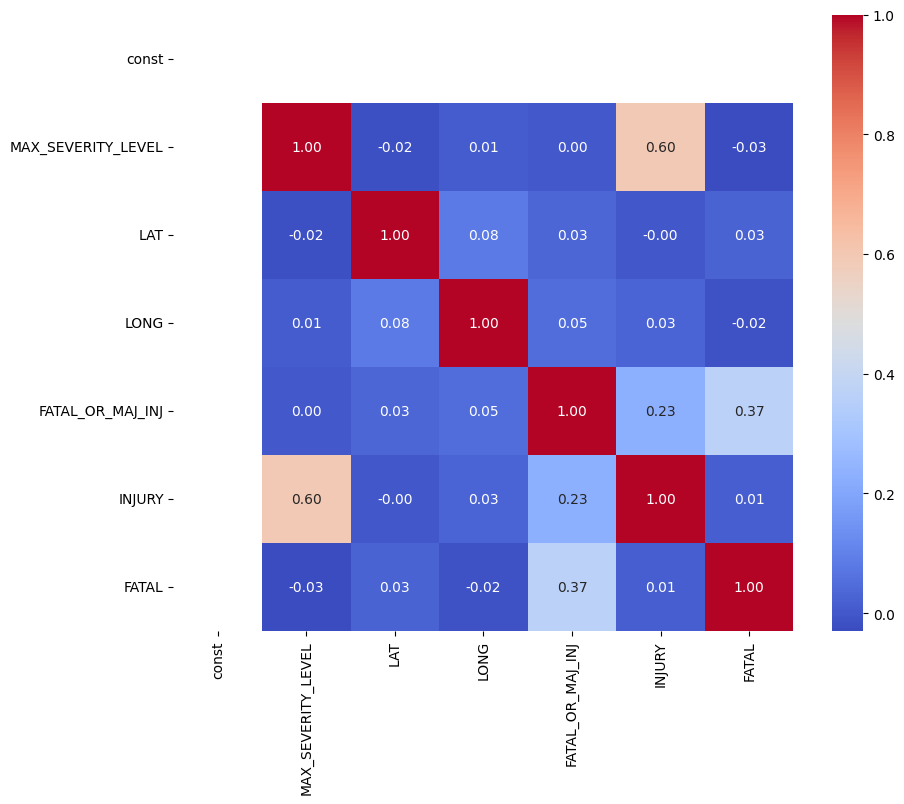

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


In [108]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.discrete.count_model as cm
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)

# 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# 4. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL','snowfall']].copy()
y = df['ACCIDENT_COUNT'].copy()

# 5. تبدیل مقادیر متنی به عددی (در صورت وجود)
for col in X.select_dtypes(include=['object']).columns:
    X[col], _ = X[col].factorize()

# 6. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# 7. حذف مقادیر خالی و همگام‌سازی ایندکس‌ها
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]  # فقط مقادیر y را که در X باقی مانده‌اند نگه داریم

# 8. مقیاس‌بندی متغیرهای مستقل
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 9. اضافه کردن مقدار ثابت (Intercept)
X_scaled = sm.add_constant(X_scaled)

# 10. همگام‌سازی نهایی ایندکس‌ها
y = y.loc[X_scaled.index]

# 11. برازش مدل ZIP
try:
    model_zip = cm.ZeroInflatedPoisson(y, X_scaled, inflation='logit').fit()
    print(model_zip.summary())
except Exception as e:
    print("خطا در اجرای مدل:", str(e))


Optimization terminated successfully.
         Current function value: 1.011226
         Iterations: 32
         Function evaluations: 33
         Gradient evaluations: 33
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:          ACCIDENT_COUNT   No. Observations:                12107
Model:             ZeroInflatedPoisson   Df Residuals:                    12099
Method:                            MLE   Df Model:                            7
Date:                 Thu, 20 Mar 2025   Pseudo R-squ.:                 0.04137
Time:                         21:33:19   Log-Likelihood:                -12243.
converged:                        True   LL-Null:                       -12771.
Covariance Type:             nonrobust   LLR p-value:                6.561e-224
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const 

In [109]:
print(X_scaled.isna().sum())  # تعداد مقادیر NaN در هر ستون
print(np.isinf(X_scaled).sum())  # تعداد مقادیر بی‌نهایت در هر ستون
print(y.isna().sum())  # بررسی مقادیر NaN در متغیر وابسته
print((y < 0).sum())  # بررسی مقادیر منفی غیرمجاز در y


const                 0
MAX_SEVERITY_LEVEL    0
LAT                   0
LONG                  0
FATAL_OR_MAJ_INJ      0
INJURY                0
FATAL                 0
snowfall              0
dtype: int64
const                 0
MAX_SEVERITY_LEVEL    0
LAT                   0
LONG                  0
FATAL_OR_MAJ_INJ      0
INJURY                0
FATAL                 0
snowfall              0
dtype: int64
0
0


In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]

print(vif_data)


              Feature       VIF
0               const  1.000000
1  MAX_SEVERITY_LEVEL  1.603327
2                 LAT  1.008322
3                LONG  1.010798
4    FATAL_OR_MAJ_INJ  1.268582
5              INJURY  1.702489
6               FATAL  1.165435
7            snowfall  1.000800


In [111]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.discrete.count_model as cm
from shapely.geometry import Point

# ✅ 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT'])

# ✅ 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else None)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else None)

# ✅ 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# ✅ 4. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']]
y = df['ACCIDENT_COUNT']

# ✅ 5. تبدیل مقادیر متنی به عددی (در صورت وجود)
for col in X.select_dtypes(include=['object']).columns:
    X[col], _ = X[col].factorize()

# ✅ 6. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# ✅ 7. حذف مقادیر خالی
X = X.dropna()
y = y.dropna()

# ✅ 8. اضافه کردن مقدار ثابت (Intercept)
X = sm.add_constant(X)

# ✅ 9. برازش مدل صفر-متورم دوجمله‌ای منفی (ZINB)
model_zinb = cm.ZeroInflatedNegativeBinomialP(y, X, inflation='logit').fit()

# ✅ 10. نمایش نتایج مدل
print(model_zinb.summary())


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1567: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + exposure + offset)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1568: RuntimeWarning: invalid value encountered in multiply
  return -np.dot(L*X.T, X)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:1478: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + offset + exposure)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1291: OptimizeWarning: NaN result enc

         Current function value: nan
         Iterations: 0
         Function evaluations: 2
         Gradient evaluations: 2


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                    ACCIDENT_COUNT   No. Observations:                12107
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                    12100
Method:                                      MLE   Df Model:                            6
Date:                           Thu, 20 Mar 2025   Pseudo R-squ.:                     nan
Time:                                   21:33:33   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                           nan
Covariance Type:                       nonrobust   LLR p-value:                       nan
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const               0        nan        nan        nan         nan         nan
const              

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # استانداردسازی متغیرهای مستقل


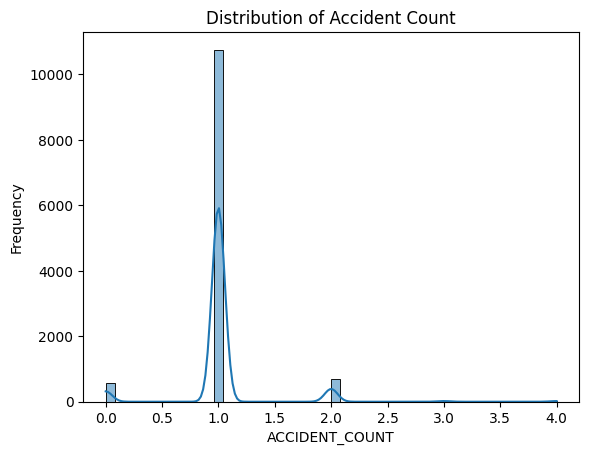

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y, bins=50, kde=True)
plt.xlabel("ACCIDENT_COUNT")
plt.ylabel("Frequency")
plt.title("Distribution of Accident Count")
plt.show()


In [114]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)


              Feature            VIF
0               const  466294.719810
1  MAX_SEVERITY_LEVEL       1.603154
2                 LAT       1.008285
3                LONG       1.010794
4    FATAL_OR_MAJ_INJ       1.268300
5              INJURY       1.701383
6               FATAL       1.165424


In [115]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from shapely.geometry import Point
import pandas as pd

# ✅ 1. حذف مقادیر خالی در متغیر هدف
df_merged = df_merged.dropna(subset=['ACCIDENT_COUNT'])

# ✅ 2. استخراج مختصات جغرافیایی از ستون geometry_y
df_merged['LAT'] = df_merged['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else None)
df_merged['LONG'] = df_merged['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else None)

# ✅ 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df_merged = df_merged.dropna(subset=['LAT', 'LONG'])

# مقیاس‌بندی داده‌ها
scaler = StandardScaler()
scaled_features = ['LAT', 'LONG', 'MAX_SEVERITY_LEVEL', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']
df_merged[scaled_features] = scaler.fit_transform(df_merged[scaled_features])

# آماده کردن داده‌ها برای مدل
X = df_merged[['LAT', 'LONG', 'MAX_SEVERITY_LEVEL', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL']]
y = df_merged['ACCIDENT_COUNT']

# مدل Zero-Inflated Negative Binomial
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
model = ZeroInflatedNegativeBinomialP(y, X, exog_infl=X)
result = model.fit()

# نمایش نتایج
print(result.summary())

# نمایش VIF برای بررسی همبستگی بیشتر
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in 

         Current function value: nan
         Iterations: 1
         Function evaluations: 112
         Gradient evaluations: 112


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                    ACCIDENT_COUNT   No. Observations:                12107
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                    12101
Method:                                      MLE   Df Model:                            5
Date:                           Thu, 20 Mar 2025   Pseudo R-squ.:                     nan
Time:                                   21:33:45   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                           nan
Covariance Type:                       nonrobust   LLR p-value:                       nan
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
inflate_LAT                   -3.1416        nan        nan        nan         nan        

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [116]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)

# 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# 4. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 5. تبدیل متغیر Day به متغیر دامیز
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# 6. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 
        'rain', 'snow_depth', 'snowfall', 'Hour_sin', 'Hour_cos'] + 
       [col for col in df.columns if col.startswith("Day_")]].copy()
y = df['ACCIDENT_COUNT'].copy()

# 7. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# 8. حذف مقادیر خالی و همگام‌سازی ایندکس‌ها
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 9. مقیاس‌بندی متغیرهای مستقل
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 10. اضافه کردن مقدار ثابت (Intercept)
X_scaled = sm.add_constant(X_scaled)

# 11. همگام‌سازی نهایی ایندکس‌ها
y = y.loc[X_scaled.index]

# 12. برازش مدل پواسون
model_poisson = sm.GLM(y, X_scaled, family=sm.families.Poisson()).fit()

# 13. نمایش خلاصه مدل
print(model_poisson.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         ACCIDENT_COUNT   No. Observations:                12107
Model:                            GLM   Df Residuals:                    12064
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12239.
Date:                Thu, 20 Mar 2025   Deviance:                       896.80
Time:                        21:33:45   Pearson chi2:                     814.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.08423
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0175      0

In [117]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)

# 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# 4. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 5. تبدیل متغیر Day به متغیر دامیز
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# 6. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 
        'rain', 'snow_depth', 'snowfall', 'Hour_sin', 'Hour_cos'] + 
       [col for col in df.columns if col.startswith("Day_")]].copy()
y = df['ACCIDENT_COUNT'].copy()

# 7. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# 8. حذف مقادیر خالی و همگام‌سازی ایندکس‌ها
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 9. مقیاس‌بندی متغیرهای مستقل
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 10. اضافه کردن مقدار ثابت (Intercept)
X_scaled = sm.add_constant(X_scaled)

# 11. همگام‌سازی نهایی ایندکس‌ها
y = y.loc[X_scaled.index]

# 12. برازش مدل منفی دوجمله‌ای
model_nb = sm.GLM(y, X_scaled, family=sm.families.NegativeBinomial()).fit()

# 13. نمایش خلاصه مدل
print(model_nb.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         ACCIDENT_COUNT   No. Observations:                12107
Model:                            GLM   Df Residuals:                    12064
Model Family:        NegativeBinomial   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16722.
Date:                Thu, 20 Mar 2025   Deviance:                       585.48
Time:                        21:33:45   Pearson chi2:                     519.
No. Iterations:                     7   Pseudo R-squ. (CS):            0.04467
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0219      0

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [118]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.discrete.count_model as cm
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)

# 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# 4. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 5. تبدیل متغیر Day به متغیر دامیز
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# 6. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 
        'rain', 'snow_depth', 'snowfall', 'Hour_sin', 'Hour_cos'] + 
       [col for col in df.columns if col.startswith("Day_")]].copy()
y = df['ACCIDENT_COUNT'].copy()

# 7. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# 8. حذف مقادیر خالی و همگام‌سازی ایندکس‌ها
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 9. مقیاس‌بندی متغیرهای مستقل
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 10. اضافه کردن مقدار ثابت (Intercept)
X_scaled = sm.add_constant(X_scaled)

# 11. همگام‌سازی نهایی ایندکس‌ها
y = y.loc[X_scaled.index]

# 12. برازش مدل پواسون صفر-متورم (ZIP)
try:
    model_zip = cm.ZeroInflatedPoisson(y, X_scaled, inflation='logit').fit()
    print(model_zip.summary())
except Exception as e:
    print("⚠️ خطا در اجرای مدل ZIP:", str(e))


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1291: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 1.010876
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:          ACCIDENT_COUNT   No. Observations:                12107
Model:             ZeroInflatedPoisson   Df Residuals:                    12064
Method:                            MLE   Df Model:                           42
Date:                 Thu, 20 Mar 2025   Pseudo R-squ.:                 0.04170
Time:                         21:33:47   Log-Likelihood:                -12239.
converged:                       False   LL-Null:                       -12771.
Covariance Type:             nonrobust   LLR p-value:                7.021e-196
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const        -22.4285    698.733     -0.032 

In [119]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.discrete.count_model as cm
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)

# 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# 4. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 5. تبدیل متغیر Day به متغیر دامیز
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# 6. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 
        'rain', 'snow_depth', 'snowfall', 'Hour_sin', 'Hour_cos'] + 
       [col for col in df.columns if col.startswith("Day_")]].copy()
y = df['ACCIDENT_COUNT'].copy()

# 7. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# 8. حذف مقادیر خالی و همگام‌سازی ایندکس‌ها
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 9. مقیاس‌بندی متغیرهای مستقل
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 10. اضافه کردن مقدار ثابت (Intercept)
X_scaled = sm.add_constant(X_scaled)

# 11. همگام‌سازی نهایی ایندکس‌ها
y = y.loc[X_scaled.index]

# 12. برازش مدل دوجمله‌ای منفی صفر-متورم (ZINB)
try:
    model_zinb = cm.ZeroInflatedNegativeBinomialP(y, X_scaled, inflation='logit').fit()
    print(model_zinb.summary())
except Exception as e:
    print("⚠️ خطا در اجرای مدل ZINB:", str(e))


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encount

         Current function value: nan
         Iterations: 1
         Function evaluations: 112
         Gradient evaluations: 112


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                    ACCIDENT_COUNT   No. Observations:                12107
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                    12064
Method:                                      MLE   Df Model:                           42
Date:                           Thu, 20 Mar 2025   Pseudo R-squ.:                     nan
Time:                                   21:34:08   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                           nan
Covariance Type:                       nonrobust   LLR p-value:                       nan
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const       -483.2867        nan        nan        nan         nan         nan
const              

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [120]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.discrete.count_model as cm
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)

# 3. حذف مقادیر NaN مربوط به مختصات جغرافیایی
df = df.dropna(subset=['LAT', 'LONG'])

# 4. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 5. تبدیل متغیر Day به متغیر دامیز
df = pd.get_dummies(df, columns=['Day'], drop_first=True)

# 6. تعریف متغیرهای مستقل و وابسته
X = df[['MAX_SEVERITY_LEVEL', 'LAT', 'LONG', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 
        'rain', 'snow_depth', 'snowfall', 'Hour_sin', 'Hour_cos'] + 
       [col for col in df.columns if col.startswith("Day_")]].copy()
y = df['ACCIDENT_COUNT'].copy()

# 7. تبدیل به عدد اعشاری
X = X.astype(float)
y = y.astype(float)

# 8. حذف مقادیر خالی و همگام‌سازی ایندکس‌ها
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 9. مقیاس‌بندی متغیرهای مستقل
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 10. اضافه کردن مقدار ثابت (Intercept)
X_scaled = sm.add_constant(X_scaled)

# 11. همگام‌سازی نهایی ایندکس‌ها
y = y.loc[X_scaled.index]

# 12. برازش مدل‌ها و محاسبه AIC و BIC
results = {}

try:
    model_poisson = sm.GLM(y, X_scaled, family=sm.families.Poisson()).fit()
    results['Poisson'] = {'AIC': model_poisson.aic, 'BIC': model_poisson.bic}
except Exception as e:
    print("⚠️ خطا در اجرای مدل پواسون:", str(e))

try:
    model_nb = sm.GLM(y, X_scaled, family=sm.families.NegativeBinomial()).fit()
    results['Negative Binomial'] = {'AIC': model_nb.aic, 'BIC': model_nb.bic}
except Exception as e:
    print("⚠️ خطا در اجرای مدل NB:", str(e))

try:
    model_zip = cm.ZeroInflatedPoisson(y, X_scaled, inflation='logit').fit()
    results['Zero-Inflated Poisson (ZIP)'] = {'AIC': model_zip.aic, 'BIC': model_zip.bic}
except Exception as e:
    print("⚠️ خطا در اجرای مدل ZIP:", str(e))

try:
    model_zinb = cm.ZeroInflatedNegativeBinomialP(y, X_scaled, inflation='logit').fit()
    results['Zero-Inflated Negative Binomial (ZINB)'] = {'AIC': model_zinb.aic, 'BIC': model_zinb.bic}
except Exception as e:
    print("⚠️ خطا در اجرای مدل ZINB:", str(e))

# 13. نمایش نتایج
results_df = pd.DataFrame(results).T
print("\n📊 **مقایسه مدل‌ها بر اساس AIC و BIC:**")
print(results_df.sort_values(by='AIC'))


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1291

         Current function value: 1.010876
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encount

         Current function value: nan
         Iterations: 1
         Function evaluations: 112
         Gradient evaluations: 112

📊 **مقایسه مدل‌ها بر اساس AIC و BIC:**
                                                 AIC            BIC
Poisson                                 24563.345574 -112523.371556
Zero-Inflated Poisson (ZIP)             24565.345599   24891.013318
Negative Binomial                       33529.046395 -112834.684145
Zero-Inflated Negative Binomial (ZINB)           NaN            NaN


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


modelhahye ezafi 

1. مدل Conway-Maxwell-Poisson (COM-Poisson)

In [121]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import GeneralizedPoisson
from sklearn.preprocessing import StandardScaler

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 3. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)
df = df.dropna(subset=['LAT', 'LONG'])

# 4. انتخاب متغیرهای بهینه‌شده
X = df[['lanes', 'maxspeed', 'highway', 'Hour_sin', 'Hour_cos', 'Day_of_Week',
        'temperature_2m', 'rain', 'snow_depth', 'wind_speed_10m',
        'MAX_SEVERITY_LEVEL', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'LAT', 'LONG']].copy()
y = df['ACCIDENT_COUNT'].copy()

# 5. پردازش داده‌ها
X = pd.get_dummies(X, columns=['highway', 'Day_of_Week'], drop_first=True) # متغیرهای کیفی به دامیز
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 6. مقیاس‌بندی
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled = sm.add_constant(X_scaled)

# 7. برازش مدل
model_com_poisson = GeneralizedPoisson(y, X_scaled).fit()
print(model_com_poisson.summary())


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_optimize.py:1291: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.894612
         Iterations: 0
         Function evaluations: 15
         Gradient evaluations: 7
                    GeneralizedPoisson Regression Results                     
Dep. Variable:         ACCIDENT_COUNT   No. Observations:                 7821
Model:             GeneralizedPoisson   Df Residuals:                     7800
Method:                           MLE   Df Model:                           20
Date:                Thu, 20 Mar 2025   Pseudo R-squ.:                   1.677
Time:                        21:34:28   Log-Likelihood:                -6996.8
converged:                      False   LL-Null:                        10332.
Covariance Type:            nonrobust   LLR p-value:                     1.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.0465        nan        nan  

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


2. مدل ترکیبی منفی دوجمله‌ای (Finite Mixture Negative Binomial)

In [122]:
from sklearn.mixture import GaussianMixture

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 3. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)
df = df.dropna(subset=['LAT', 'LONG'])

# 4. انتخاب متغیرهای بهینه‌شده
X = df[['lanes', 'maxspeed', 'highway', 'Hour_sin', 'Hour_cos', 'Day_of_Week',
        'temperature_2m', 'rain', 'snow_depth', 'wind_speed_10m',
        'MAX_SEVERITY_LEVEL', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'LAT', 'LONG']].copy()
y = df['ACCIDENT_COUNT'].copy()

# 5. پردازش داده‌ها
X = pd.get_dummies(X, columns=['highway', 'Day_of_Week'], drop_first=True)
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 6. مقیاس‌بندی
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 7. اجرای مدل ترکیبی منفی دوجمله‌ای
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# 8. نمایش نتایج
print("Means of the Components:")
print(gmm.means_)
print("\nCovariances of the Components:")
print(gmm.covariances_)
print("\nWeights of the Components:")
print(gmm.weights_)


Means of the Components:
[[-1.59889071e-02  3.00026490e-02  2.29467670e-02  3.78517336e-02
  -5.67766888e-02  7.40148689e-03  1.73023277e-02  2.39963675e-02
  -7.05117608e-01 -1.74998570e-01 -7.74621486e-01 -6.60776168e-02
   8.48105168e-03 -3.98357373e-02 -2.72821250e-02  1.10803603e-02
   6.31789795e-03  1.87154105e-02 -2.22162705e-02  9.64889617e-05]
 [ 2.08987750e-02 -3.92158518e-02 -2.99932521e-02 -4.94752305e-02
   7.42116543e-02 -9.67433287e-03 -2.26155204e-02 -3.13651636e-02
   9.21644873e-01  2.28737069e-01  1.01249198e+00  8.63687080e-02
  -1.10854100e-02  5.20684814e-02  3.56599103e-02 -1.44829134e-02
  -8.25799581e-03 -2.44625322e-02  2.90384350e-02 -1.26118758e-04]]

Covariances of the Components:
[[[ 9.08961719e-01  1.86222671e-01  7.33781371e-02  1.47735634e-02
   -9.73428969e-03 -1.42397816e-02 -1.03246165e-03 -4.81045651e-03
    3.13564643e-29  1.55870797e-29 -6.19837086e-29 -7.94735970e-31
   -1.08747034e-01  5.94217071e-02 -4.19237105e-01 -1.33893040e-02
    4.503709

In [125]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 3. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if isinstance(point, Point) else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if isinstance(point, Point) else np.nan)
df = df.dropna(subset=['LAT', 'LONG'])

# 4. انتخاب متغیرهای بهینه‌شده
X = df[['lanes', 'maxspeed', 'highway', 'Hour_sin', 'Hour_cos', 'Day_of_Week',
        'temperature_2m', 'rain', 'snow_depth', 'wind_speed_10m',
        'MAX_SEVERITY_LEVEL', 'FATAL_OR_MAJ_INJ', 'INJURY', 'FATAL', 'LAT', 'LONG']].copy()
y = df['ACCIDENT_COUNT'].copy()

# 5. پردازش داده‌ها
X = pd.get_dummies(X, columns=['highway', 'Day_of_Week'], drop_first=True)
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# 6. مقیاس‌بندی
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 7. اجرای مدل ترکیبی GaussianMixture
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

# 8. محاسبه AIC، BIC و Log-Likelihood
aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)
log_likelihood = gmm.score(X_scaled) * X_scaled.shape[0]  # محاسبه Log-Likelihood به طور دستی

# 9. نمایش نتایج
print("AIC:", aic)
print("BIC:", bic)
print("Log-Likelihood:", log_likelihood)


AIC: 174943.9211589506
BIC: 178154.58686984994
Log-Likelihood: -87010.9605794753


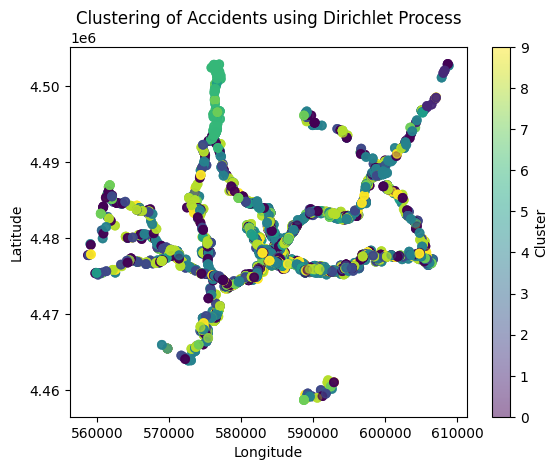

In [123]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import BayesianGaussianMixture
import matplotlib.pyplot as plt

# 1. حذف مقادیر خالی در متغیر هدف
df = df_merged.dropna(subset=['ACCIDENT_COUNT']).copy()

# 2. تبدیل متغیرهای زمانی
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

# 3. استخراج مختصات جغرافیایی
df['LAT'] = df['geometry_y'].apply(lambda point: point.y if hasattr(point, 'y') else np.nan)
df['LONG'] = df['geometry_y'].apply(lambda point: point.x if hasattr(point, 'x') else np.nan)
df = df.dropna(subset=['LAT', 'LONG'])

# 4. انتخاب ویژگی‌ها
X = df[['ACCIDENT_COUNT', 'LAT', 'LONG', 'Hour_sin', 'Hour_cos']].copy()

# 5. مقیاس‌بندی داده‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. مدل فرآیند دیریشله با sklearn
dpgmm = BayesianGaussianMixture(n_components=10, weight_concentration_prior=0.1, covariance_type="full", random_state=42)
df['Cluster'] = dpgmm.fit_predict(X_scaled)

# 7. نمایش نتایج
plt.scatter(df['LONG'], df['LAT'], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clustering of Accidents using Dirichlet Process")
plt.colorbar(label="Cluster")
plt.show()
